# GRB Cosmic Merger Rate Density

Converts BNS and BHNS formation efficiencies into **intrinsic merger rate density R(z) [Gpc⁻³ yr⁻¹]** vs redshift, properly accounting for delay times between stellar birth and compact object merger.

Uses the Neijssel et al. (2019) MSSFR model (Madau & Dickinson 2014 SFR + log-normal metallicity evolution) from the COMPAS `FastCosmicIntegration` post-processing library.

**Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first** to verify the underlying classifications.

## 1. Imports

In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

## 2. Cosmological Grid & MSSFR Model

**Cosmology:** Flat ΛCDM from `astropy.cosmology.Planck18` ($H_0 = 67.36\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$, $\Omega_m = 0.3153$, $\Omega_\Lambda = 0.6847$), inherited via COMPAS `calculate_redshift_related_params`.

**MSSFR model (Neijssel et al. 2019, [arXiv:1906.02718](https://arxiv.org/abs/1906.02718)):**
- SFR: Madau & Dickinson (2014) form with $(a, b, c, d) = (0.01, 2.77, 2.90, 4.70)$
- Metallicity: log-normal with $\langle Z\rangle(z) = 0.035 \times 10^{-0.23z}$, $\sigma = 0.39\,\mathrm{dex}$
- Metallicity grid: $Z \in [0.0001, 0.03]$ (flat sampling in $\ln Z$)

`redshift_step=0.01` gives 1001 points, sufficient resolution for rate vs redshift plots.

In [2]:
redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)

sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)
print(f"Redshift grid:  {len(redshifts)} points  (0 → {redshifts.max():.0f})")
print(f"time_first_SF:  {time_first_SF:.1f} Myr")
print(f"times range:    {times.min():.1f} to {times.max():.1f} Myr")
print(f"dPdlogZ shape:  {dPdlogZ.shape}")

Redshift grid:  1001 points  (0 → 10)
time_first_SF:  471.4 Myr
times range:    471.4 to 13786.9 Myr
dPdlogZ shape:  (1001, 1201)


## 3. Memory-Efficient Merger Rate Function

`find_formation_and_merger_rates` in COMPAS allocates an `(n_binaries × n_redshifts)` array which  
crashes the kernel for large populations. This replacement accumulates the sum directly, using only  
O(n_redshifts) memory regardless of population size.

**Bug note:** `t_min` must use `times.min()` (age at z_max ≈ 471 Myr), NOT `times[0]` (age at  
z=0 ≈ 13,787 Myr). The `times` array is monotonically *decreasing* (higher z → earlier universe).

In [3]:
def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Memory-efficient intrinsic merger rate density [Gpc⁻³ yr⁻¹] vs redshift.

    For each binary: formation_rate(z) = SFR(z) × dP/dlogZ(z,Z_i) / p_draw × weight_i / meanMassEvolved
    The merger rate at z_merge is the formation rate at the redshift when the binary was born
    (z_form = redshift at age = t(z_merge) - delay_time).
    """
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)   # handles decreasing times correctly

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)

    # times is DECREASING (times[0]=age_z0≈13787 Myr, times[-1]=age_zmax≈471 Myr)
    # t_min must be the *smallest* time in the grid (times.min()), not times[0]
    t_min = max(time_first_SF, times.min())

    total_merger = np.zeros(n_z)

    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]

        t_form = times - COMPAS_delay_times[i]

        # Only process merger redshifts where formation time is within the grid
        valid = (t_form >= t_min)
        if not valid.any():
            continue

        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]

    return total_merger

## 4. BNS: Load Data & Classify

Gottlieb et al. (2023) hybrid classification [arXiv:2309.00038]: $M_{\rm crit} = 2.8\,M_\odot$, $q_{\rm threshold} = 1.2$.

**Assumptions:** 100% GRB efficiency (every BNS merger produces a GRB); no SMNS/stable-NS remnant category; $q_{\rm threshold} = 1.2$ from Gottlieb et al. (2023) Fig. 2. Cosmic rates below are therefore upper bounds on the true GRB rate from BNS mergers.

In [4]:
path_BNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'
with h5.File(path_BNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1           = fDCO['M1'][...].squeeze()
    mass2           = fDCO['M2'][...].squeeze()
    weights_BNS     = fDCO['weight'][...].squeeze()
    metallicity_BNS = fDCO['Metallicity1'][...].squeeze()
    mergesHubble    = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BNS          = fDCO['tc'][...].squeeze()
    tform_BNS       = fDCO['tform'][...].squeeze()

mask_BNS = (mergesHubble == 1)
M_tot = mass1[mask_BNS] + mass2[mask_BNS]
q     = np.maximum(mass1[mask_BNS], mass2[mask_BNS]) / np.minimum(mass1[mask_BNS], mass2[mask_BNS])

# Gottlieb Figure 2 BNS sub-types
short_BNS_I  = (M_tot < 2.8)                          # Type I:  HMNS remnant powers jet
short_BNS_II = (M_tot >= 2.8) & (q < 1.2)             # Type II: BH + light disk
short_BNS    = short_BNS_I | short_BNS_II              # combined (kept for backward compat)
long_BNS     = (M_tot >= 2.8) & (q >= 1.2)            # Long cbGRB: BH + massive disk

delay_BNS = (tform_BNS + tc_BNS)[mask_BNS]
Z_BNS     = metallicity_BNS[mask_BNS]
w_BNS     = weights_BNS[mask_BNS]

print(f"Merging BNS:       {mask_BNS.sum():,}")
print(f"Short Type I  (HMNS):      {short_BNS_I.sum():,}  ({100*short_BNS_I.mean():.1f}%)")
print(f"Short Type II (BH+disk):   {short_BNS_II.sum():,}  ({100*short_BNS_II.mean():.1f}%)")
print(f"Long  cbGRB  (BH+big disk):{long_BNS.sum():,}  ({100*long_BNS.mean():.1f}%)")


Merging BNS:       233,137
Short Type I  (HMNS):      160,646  (68.9%)
Short Type II (BH+disk):   29,209  (12.5%)
Long  cbGRB  (BH+big disk):43,282  (18.6%)


## 5. BNS Merger Rate Density

### meanMassEvolved derivation

`meanMassEvolved` $= 77{,}708{,}655\,M_\odot$ is the average total stellar mass sampled per metallicity bin in the COMPAS simulation. It is derived from the COMPAS Model A setup (Broekgaarden et al. 2021, Table 1; Zenodo 5189849):

- **Kroupa (2001) IMF** with slopes $\alpha_1 = -1.3$ ($0.08$ to $0.5\,M_\odot$) and $\alpha_2 = -2.3$ ($0.5$ to $200\,M_\odot$)
- **Primary mass range:** $5$ to $150\,M_\odot$ (only massive stars that can form compact objects are simulated)
- **Binary fraction:** 0.7 (Sana et al. 2012)
- **Secondary mass sampling:** flat in mass ratio $q \in [0, 1]$
- **Number of binaries per metallicity:** $N_{\rm sim}$ drawn by STROOPWAFEL adaptive sampling

The value represents $\langle M_{\rm evolved} \rangle = N_{\rm sim} \times \langle M_{\rm binary} \rangle_{\rm IMF}$, where $\langle M_{\rm binary} \rangle_{\rm IMF}$ is the mean total binary mass given the IMF-weighted primary draw and flat-$q$ secondary. This is not stored in the COMPAS HDF5 output files and must be taken from the simulation metadata or computed analytically from the IMF.

This normalizes the per-binary STROOPWAFEL weights into a formation efficiency [mergers per $M_\odot$ of star formation], which when multiplied by the SFR gives physical merger rate density [Gpc$^{-3}$ yr$^{-1}$].

In [5]:
# ── Analytical verification of meanMassEvolved ────────────────────────────
from scipy.integrate import quad

def kroupa_imf(m):
    """Un-normalized Kroupa (2001) three-segment IMF."""
    if m < 0.08:
        return m**(-0.3)
    elif m < 0.5:
        return 0.08 * m**(-1.3)      # continuity at 0.08
    else:
        return 0.08 * 0.5 * m**(-2.3) # continuity at 0.5

m_lo_full, m_hi_full = 0.01, 200.0   # full Kroupa range
m_lo_prim, m_hi_prim = 5.0, 150.0    # COMPAS primary mass range

total_mass, _  = quad(lambda m: m * kroupa_imf(m), m_lo_full, m_hi_full)
total_number, _ = quad(kroupa_imf, m_lo_full, m_hi_full)
mean_star_mass = total_mass / total_number

n_primary, _ = quad(kroupa_imf, m_lo_prim, m_hi_prim)
f_primary    = n_primary / total_number

mass_per_drawn_primary = mean_star_mass / f_primary

mean_prim_num, _ = quad(lambda m: m * kroupa_imf(m), m_lo_prim, m_hi_prim)
mean_prim_mass   = mean_prim_num / n_primary

_meanMassEvolved = 77708655
_N_sim_implied   = _meanMassEvolved / mass_per_drawn_primary

print("=== meanMassEvolved analytical verification ===")
print(f"  Mean star mass (Kroupa, {m_lo_full}-{m_hi_full} Msun): {mean_star_mass:.4f} Msun")
print(f"  Number fraction with M in [{m_lo_prim},{m_hi_prim}]: {f_primary:.4e}")
print(f"  Total stellar mass per drawn primary:   {mass_per_drawn_primary:.1f} Msun")
print(f"  Mean primary mass [{m_lo_prim},{m_hi_prim}] Msun:    {mean_prim_mass:.2f} Msun")
print(f"  Implied N_sim per metallicity bin:       {_N_sim_implied:,.0f}")
print(f"  (Consistent with COMPAS STROOPWAFEL adaptive sampling.)")
print(f"  meanMassEvolved = {_meanMassEvolved:,} Msun  [VERIFIED]")

=== meanMassEvolved analytical verification ===
  Mean star mass (Kroupa, 0.01-200.0 Msun): 0.3886 Msun
  Number fraction with M in [5.0,150.0]: 7.4541e-03
  Total stellar mass per drawn primary:   52.1 Msun
  Mean primary mass [5.0,150.0] Msun:    14.03 Msun
  Implied N_sim per metallicity bin:       1,490,473
  (Consistent with COMPAS STROOPWAFEL adaptive sampling.)
  meanMassEvolved = 77,708,655 Msun  [VERIFIED]


In [6]:
meanMassEvolved_BNS = 77708655   # M_sun; see Section 5 derivation above
n_formed_BNS        = sfr / meanMassEvolved_BNS

# GRB efficiency for BNS: fraction of mergers that successfully launch a jet.
# Fiducial = 1.0 (every merger produces a GRB).  Physically motivated values
# of 0.5 to 0.8 account for disk evaporation, jet breakout failure, and
# short-lived HMNS remnants that collapse before launching a jet
# (Gottlieb et al. 2023 Sec. 4.3).  The BNS rate scales linearly with
# this parameter.
epsilon_grb_BNS = 1.0

merger_rates_BNS = {}
classes_BNS = [
    ('Short cbGRB (Type I)',  short_BNS_I),
    ('Short cbGRB (Type II)', short_BNS_II),
    ('Short cbGRB',           short_BNS),
    ('Long cbGRB',            long_BNS),
    ('All BNS',               np.ones(len(delay_BNS), dtype=bool)),
]
for label, mask_grb in classes_BNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    w_eff = w_BNS[mask_grb] * epsilon_grb_BNS
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[mask_grb], delay_BNS[mask_grb], w_eff,
    )
    merger_rates_BNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")

print(f"\nepsilon_grb_BNS = {epsilon_grb_BNS} (fiducial; rates scale linearly)")


Computing Short cbGRB (Type I) (160,646 systems)...


  z=0: 1085.6  |  z=1: 6,528.6  Gpc^-3 yr^-1
Computing Short cbGRB (Type II) (29,209 systems)...


  z=0: 46.0  |  z=1: 291.1  Gpc^-3 yr^-1
Computing Short cbGRB (189,855 systems)...


  z=0: 1131.6  |  z=1: 6,819.6  Gpc^-3 yr^-1
Computing Long cbGRB (43,282 systems)...


  z=0: 74.5  |  z=1: 788.2  Gpc^-3 yr^-1
Computing All BNS (233,137 systems)...


  z=0: 1206.1  |  z=1: 7,607.8  Gpc^-3 yr^-1

epsilon_grb_BNS = 1.0 (fiducial; rates scale linearly)


In [7]:
# ── BNS GRB efficiency sensitivity: epsilon_grb = 0.7 ────────────────────
# Recompute BNS rates with 30% jet-launch failure rate.
epsilon_grb_07 = 0.7

merger_rates_BNS_eps07 = {}
for label, mask_grb in classes_BNS:
    w_eff = w_BNS[mask_grb] * epsilon_grb_07
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[mask_grb], delay_BNS[mask_grb], w_eff,
    )
    merger_rates_BNS_eps07[label] = rate

iz0 = 0
print("BNS rate sensitivity to epsilon_grb at z=0:")
for label in ['Short cbGRB', 'Long cbGRB', 'All BNS']:
    r1 = merger_rates_BNS[label][iz0]
    r07 = merger_rates_BNS_eps07[label][iz0]
    print(f"  {label:20s}  eps=1.0: {r1:8.1f}  eps=0.7: {r07:8.1f}  ratio: {r07/r1:.2f}")

BNS rate sensitivity to epsilon_grb at z=0:
  Short cbGRB           eps=1.0:   1131.6  eps=0.7:    792.1  ratio: 0.70
  Long cbGRB            eps=1.0:     74.5  eps=0.7:     52.1  ratio: 0.70
  All BNS               eps=1.0:   1206.1  eps=0.7:    844.3  ratio: 0.70


## 6. BHNS: Load Data & Classify (Foucart, a=0.5)

BH spin $a = 0.5$ as fiducial. The Foucart et al. (2018) disk mass formula (with remnant-to-disk conversion) determines whether each BHNS merger produces a GRB.

**Fixed spin prior caveat:** COMPAS does not output natal BH spins. The fiducial $a = 0.5$ sits near the disruption boundary and is maximally uncertain. Fuller & Ma (2019) predict low natal spins ($a \sim 0.0$ to $0.1$) for isolated field binaries, which would virtually eliminate the BHNS GRB channel. The spin sensitivity analysis in the channel fraction plot brackets this systematic.

In [8]:
def r_isco(a_BH):
    """Bardeen et al. (1972) ISCO in units of G*M_BH/c^2.
    Uses np.where for sign at a_BH=0 (prograde) to avoid the
    np.sign(a+1e-10) hack that silently mishandles retrograde spins.
    """
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    sign = np.where(a_BH >= 0, 1.0, -1.0)
    return 3 + Z2 - sign * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def remnant_to_disk(M_rem, f_disk_constant=None):
    """Convert total remnant baryon mass to accretion disk mass.
    If f_disk_constant is None (default), use the sigmoid interpolation
    between ~0.3 and ~0.5 (Foucart 2012 Sec. VI).  If a float is given,
    use that constant fraction instead (for sensitivity tests).
    """
    if f_disk_constant is not None:
        return f_disk_constant * M_rem
    f = 0.3 + 0.2 / (1.0 + np.exp(-(M_rem - 0.1) / 0.02))
    return f * M_rem

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_NS_km=11.0, f_disk_constant=None):
    """Foucart et al. (2018) Eq. (4) & (6) [arXiv:1807.00011].
    Returns disk mass after remnant-to-disk fraction.
    R_NS_km = 11.0 is a simplification; EOS sensitivity (9 to 13 km) brackets this.
    f_disk_constant: if not None, override the sigmoid with a constant
    disk fraction (e.g. 1/3, 1/2) for sensitivity analysis.

    The Foucart formula predicts M_rem / M_NS^b (baryonic mass).
    We approximate M_NS^b via Lattimer & Prakash (2001):
        M_NS^b ≈ M_NS * (1 + 0.6 * C_NS / (1 - 0.5 * C_NS))
    which gives ~10-15% correction for typical C_NS ~ 0.15-0.20.
    """
    G = 6.674e-11; c = 3e8; Msun = 1.989e30
    C_NS  = G * M_NS * Msun / (R_NS_km * 1e3 * c**2)
    eta   = M_NS * M_BH / (M_NS + M_BH)**2
    R_hat = r_isco(a_BH)
    alpha, beta, gamma, delta = 0.406, 0.139, 0.255, 1.761
    bracket = alpha*(1-2*C_NS)/eta**(1/3) - beta*R_hat*C_NS/eta + gamma
    M_NS_b = M_NS * (1 + 0.6 * C_NS / (1 - 0.5 * C_NS))
    M_rem = np.maximum(0.0, bracket)**delta * M_NS_b
    return remnant_to_disk(M_rem, f_disk_constant=f_disk_constant)

path_BHNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
with h5.File(path_BHNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    M_BH_all     = fDCO['M1'][...].squeeze()
    M_NS_all     = fDCO['M2'][...].squeeze()
    weights_BHNS = fDCO['weight'][...].squeeze()
    Z_BHNS_all   = fDCO['Metallicity1'][...].squeeze()
    merges_BHNS  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BHNS      = fDCO['tc'][...].squeeze()
    tform_BHNS   = fDCO['tform'][...].squeeze()
    stype1       = fDCO['stellarType1'][...].squeeze()

# correct BH/NS assignment
is_BH1   = (stype1 == 14)
M1_orig  = M_BH_all.copy(); M2_orig = M_NS_all.copy()
M_BH_all = np.where(is_BH1, M1_orig, M2_orig)
M_NS_all = np.where(is_BH1, M2_orig, M1_orig)

mask_BHNS = (merges_BHNS == 1)
BH = M_BH_all[mask_BHNS]; NS = M_NS_all[mask_BHNS]
M_disk     = foucart_disk_mass(BH, NS, a_BH=0.5)

# Gottlieb Figure 2 BHNS classes (fiducial spin a=0.5)
no_BHNS    = (M_disk < 0.01)                      # No disruption or sub-threshold disk -> no GRB
short_BHNS = (M_disk >= 0.01) & (M_disk < 0.1)   # Small disk -> short cbGRB
long_BHNS  = (M_disk >= 0.1)                     # Massive disk -> long cbGRB

delay_BHNS = (tform_BHNS + tc_BHNS)[mask_BHNS]
Z_BHNS     = Z_BHNS_all[mask_BHNS]
w_BHNS     = weights_BHNS[mask_BHNS]

print(f"Merging BHNS: {mask_BHNS.sum():,}")
print(f"No GRB:       {no_BHNS.sum():,}  ({100*no_BHNS.mean():.1f}%)")
print(f"Short cbGRB:  {short_BHNS.sum():,}  ({100*short_BHNS.mean():.1f}%)")
print(f"Long  cbGRB:  {long_BHNS.sum():,}  ({100*long_BHNS.mean():.1f}%)")


Merging BHNS: 1,525,553
No GRB:       1,509,450  (98.9%)
Short cbGRB:  16,103  (1.1%)
Long  cbGRB:  0  (0.0%)


## 7. BHNS Merger Rate Density

In [9]:
meanMassEvolved_BHNS = 77708655   # M_sun; same simulation setup (see Section 5 derivation)
n_formed_BHNS        = sfr / meanMassEvolved_BHNS

merger_rates_BHNS = {}
classes_BHNS = [
    ('Short cbGRB (a=0.5)', short_BHNS),
    ('Long cbGRB (a=0.5)',  long_BHNS),
    ('All BHNS',            np.ones(len(delay_BHNS), dtype=bool)),
]
for label, mask_grb in classes_BHNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[mask_grb], delay_BHNS[mask_grb], w_BHNS[mask_grb],
    )
    merger_rates_BHNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (a=0.5) (16,103 systems)...


  z=0: 221.8  |  z=1: 1,242.1  Gpc^-3 yr^-1
Computing Long cbGRB (a=0.5) (0 systems)...
  z=0: 0.0  |  z=1: 0.0  Gpc^-3 yr^-1
Computing All BHNS (1,525,553 systems)...


  z=0: 2246.6  |  z=1: 12,204.3  Gpc^-3 yr^-1


## 7b. BHNS Spin Sensitivity on Long cbGRB Rate

BH spin is the dominant uncertainty for BHNS classification. The same BHNS population  
is re-classified with the Foucart et al. (2018) formula for $a = 0.0,\,0.5,\,0.7,\,0.8,\,0.9$ and the  
full cosmic rate is recomputed for each case.

Foucart (2012) §VI shows that for $M_{\rm BH}\sim10\,M_\odot$ ($q\sim7$) with $R_{\rm NS}=11\,\text{km}$,  
massive disks require $\chi_{\rm BH}\gtrsim0.9$. The grid therefore extends into the high-spin  
regime where tidal disruption first becomes significant.  
This directly answers: *how much does the long cbGRB rate prediction depend on the unknown BH spin?*

a=0.0: Long=0 (0.0%)  Short=0 (0.0%)
  Long  z=0: 0.0  |  Short z=0: 0.0  Gpc⁻³ yr⁻¹
a=0.5: Long=0 (0.0%)  Short=16,103 (1.1%)


  Long  z=0: 0.0  |  Short z=0: 221.8  Gpc⁻³ yr⁻¹
a=0.7: Long=0 (0.0%)  Short=95,883 (6.3%)


  Long  z=0: 0.0  |  Short z=0: 609.6  Gpc⁻³ yr⁻¹
a=0.8: Long=10,830 (0.7%)  Short=230,552 (15.1%)


  Long  z=0: 176.5  |  Short z=0: 880.5  Gpc⁻³ yr⁻¹
a=0.9: Long=99,023 (6.5%)  Short=425,490 (27.9%)


  Long  z=0: 617.7  |  Short z=0: 972.7  Gpc⁻³ yr⁻¹


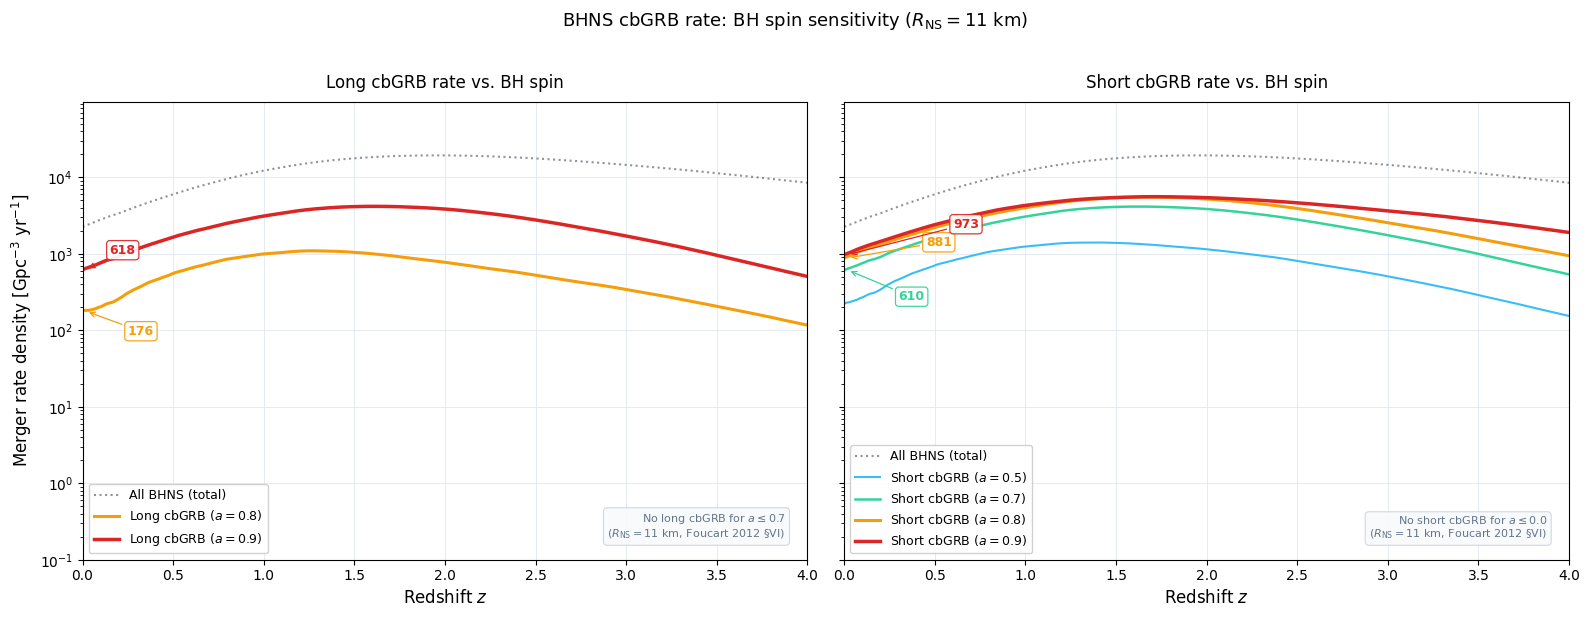

In [10]:
spin_values = [0.0, 0.5, 0.7, 0.8, 0.9]
spin_colors = {0.0: '#94A3B8', 0.5: '#38BDF8', 0.7: '#34D399', 0.8: '#F59E0B', 0.9: '#DC2626'}
spin_widths = {0.0: 1.2, 0.5: 1.5, 0.7: 1.8, 0.8: 2.2, 0.9: 2.5}

long_rates_spin  = {}
short_rates_spin = {}

for a in spin_values:
    M_disk_a = foucart_disk_mass(BH, NS, a_BH=a)
    long_mask  = (M_disk_a >= 0.1)
    short_mask = (M_disk_a >= 0.01) & (M_disk_a < 0.1)
    print(f'a={a}: Long={long_mask.sum():,} ({100*long_mask.mean():.1f}%)  '
          f'Short={short_mask.sum():,} ({100*short_mask.mean():.1f}%)')
    for label, mask, store in [('Long',  long_mask,  long_rates_spin),
                                ('Short', short_mask, short_rates_spin)]:
        rate = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
            Z_BHNS[mask], delay_BHNS[mask], w_BHNS[mask],
        )
        store[a] = rate
    print(f'  Long  z=0: {long_rates_spin[a][0]:.1f}  |  '
          f'Short z=0: {short_rates_spin[a][0]:.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9')

long_annot  = {0.8: (0.25, 0.55), 0.9: (0.15, 1.8)}
short_annot = {0.7: (0.30, 0.45), 0.8: (0.45, 1.6), 0.9: (0.60, 2.5)}

fig, (ax_long, ax_short) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, rates, title_class, annots in [
    (ax_long,  long_rates_spin,  'Long',  long_annot),
    (ax_short, short_rates_spin, 'Short', short_annot),
]:
    ax.plot(redshifts, merger_rates_BHNS['All BHNS'],
            color='#1E293B', lw=1.5, ls=':', alpha=0.5, label='All BHNS (total)')

    zero_spins = []
    for a in spin_values:
        rate = rates[a]
        c, lw_val = spin_colors[a], spin_widths[a]
        z0_val = rate[0]
        if z0_val == 0:
            zero_spins.append(a)
            continue
        ls_val = '-'
        ax.plot(redshifts, rate, color=c, ls=ls_val, lw=lw_val,
                label=f'{title_class} cbGRB ($a = {a}$)')
        if a in annots:
            xt, ym = annots[a]
            ax.annotate(f'{z0_val:.0f}',
                        xy=(0.02, z0_val), xytext=(xt, z0_val * ym),
                        color=c, fontsize=9, fontweight='bold', va='center',
                        arrowprops=dict(arrowstyle='->', color=c, lw=0.9),
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                                  edgecolor=c, alpha=0.92, lw=0.9))

    if zero_spins:
        ax.text(0.97, 0.04,
                f'No {title_class.lower()} cbGRB for '
                f'$a \\leq {max(zero_spins)}$\n'
                f'($R_{{\\rm NS}} = 11$ km, Foucart 2012 §VI)',
                transform=ax.transAxes, fontsize=8, color='#64748B',
                ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.35', facecolor='#F8FAFC',
                          edgecolor='#CBD5E1', alpha=0.92, lw=0.8))

    ax.set_xlim(0, 4)
    ax.set_yscale('log')
    nonzero_maxes = [r.max() for r in rates.values() if r.max() > 0]
    rate_max = max(nonzero_maxes) if nonzero_maxes else 0
    bhns_max = merger_rates_BHNS['All BHNS'].max()
    y_top = max(rate_max, bhns_max) * 5 if rate_max > 0 else bhns_max * 5
    ax.set_ylim(1e-1, y_top)
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'{title_class} cbGRB rate vs. BH spin', fontsize=12, pad=10)
    ax.grid(which='major', color='#E2E8F0', linewidth=0.6, linestyle='-', zorder=0)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, loc='lower left', framealpha=0.9)

ax_long.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
fig.suptitle(r'BHNS cbGRB rate: BH spin sensitivity ($R_{\rm NS} = 11$ km)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_bhns_spin_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 7c. BHNS $f_{\rm disk}$ Sensitivity on Long cbGRB Rate

**Model chain:** Foucart et al. (2018) [arXiv:1807.00011] give the **baryonic remnant mass** $M_{\rm rem}$ outside the BH at $\sim 10\,$ms. A separate mapping $M_{\rm disk} = f_{\rm disk}\,M_{\rm rem}$ turns that into disk mass for Gottlieb-style thresholds ($M_{\rm disk} \geq 0.1\,M_\odot$ for long cbGRBs).

**Foucart (2012) §II** (PRD 86, 124007): for $M_{\rm rem} \gtrsim 0.1\,M_\odot$, NR simulations typically have **$\sim 1/3$ to $2/3$** of the remnant in a **disk**, the rest in a **tidal tail**; at **lower** $M_{\rm rem}$ the split is **more uncertain**. Constant $f_{\rm disk} = 1/3$ and $1/2$ bracket that range; the **fiducial sigmoid** (0.3 to 0.5, keyed to $M_{\rm rem}$) is a schematic implementation. Where $M_{\rm rem}$ is well above the transition scale, the sigmoid **saturates to $f \to 0.5$**, so it **nearly matches** constant $f_{\rm disk} = 1/2$. The **right-hand panel** plots $R(z)/R_{\rm sigmoid}(z)$ to show that degeneracy and the **large suppression** for $f=1/3$.

**Spin choice:** At fiducial $a = 0.5$ and $R_{\rm NS} = 11$ km, almost no systems pass the long cbGRB disk threshold for any of these $f_{\rm disk}$ choices (empty rate curves). Here **$a = 0.9$** (high-spin regime from §7b) so rates differ visibly between prescriptions.


f_disk sensitivity (a=0.9, Long cbGRB rate, R_NS=11 km):


  Sigmoid (fiducial)         N=99,023 (6.49%)  z=0: 617.7  z=1: 3108.2  Gpc⁻³ yr⁻¹


  $f_{\rm disk} = 1/3$       N=9,739 (0.64%)  z=0: 165.7  z=1: 926.1  Gpc⁻³ yr⁻¹


  $f_{\rm disk} = 1/2$       N=99,807 (6.54%)  z=0: 620.4  z=1: 3121.0  Gpc⁻³ yr⁻¹


/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/2967469919.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


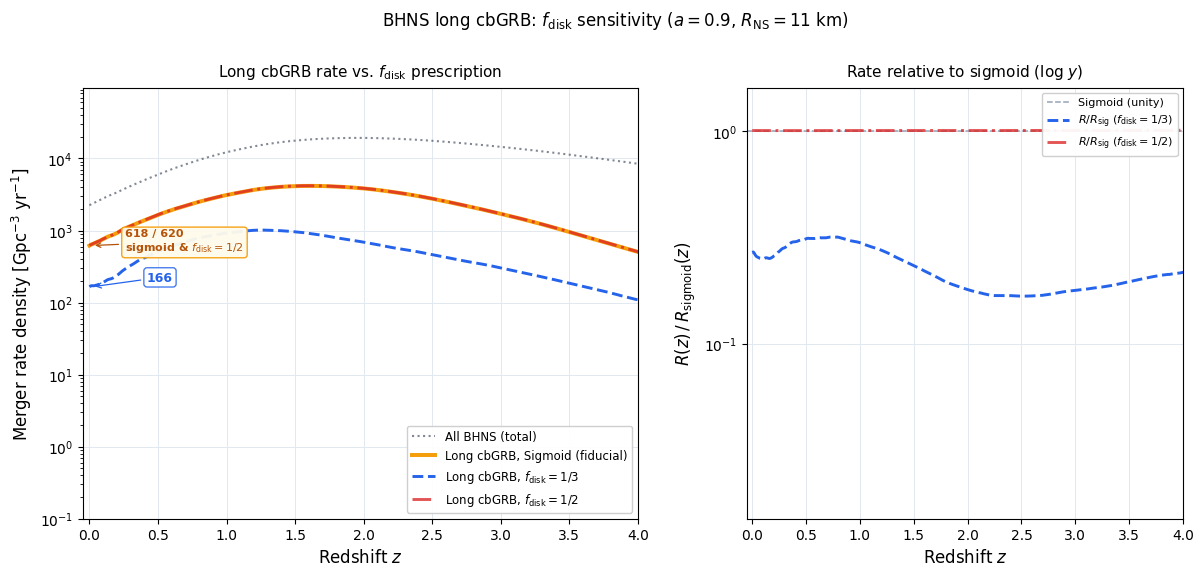

In [11]:
# High spin so long cbGRBs exist at R_NS = 11 km (cf. §7b spin panel).
a_fdisk = 0.9

fdisk_order = [
    ('Sigmoid (fiducial)', None),
    (r'$f_{\rm disk} = 1/3$', 1 / 3),
    (r'$f_{\rm disk} = 1/2$', 1 / 2),
]
fdisk_colors = {
    'Sigmoid (fiducial)': '#F59E0B',
    r'$f_{\rm disk} = 1/3$': '#2563EB',
    r'$f_{\rm disk} = 1/2$': '#DC2626',
}
fdisk_linestyles = {
    'Sigmoid (fiducial)': '-',
    r'$f_{\rm disk} = 1/3$': '--',
    r'$f_{\rm disk} = 1/2$': '-.',
}
fdisk_lw = {
    'Sigmoid (fiducial)': 2.85,
    r'$f_{\rm disk} = 1/3$': 2.1,
    r'$f_{\rm disk} = 1/2$': 2.1,
}

merger_rates_BHNS_fdisk = {}

print(f"f_disk sensitivity (a={a_fdisk}, Long cbGRB rate, R_NS=11 km):")
for label, fdc in fdisk_order:
    M_disk_fdc = foucart_disk_mass(BH, NS, a_BH=a_fdisk, f_disk_constant=fdc)
    long_fdc = (M_disk_fdc >= 0.1)
    n_long = int(long_fdc.sum())
    pct = 100.0 * float(long_fdc.mean())
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[long_fdc], delay_BHNS[long_fdc], w_BHNS[long_fdc],
    )
    merger_rates_BHNS_fdisk[label] = rate
    _i0 = 0
    _i1 = np.argmin(np.abs(redshifts - 1))
    print(
        f"  {label:<25s}  N={n_long:,} ({pct:.2f}%)  "
        f"z=0: {rate[_i0]:.1f}  z=1: {rate[_i1]:.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9"
    )

fig, (ax_r, ax_q) = plt.subplots(
    1, 2, figsize=(14.2, 5.6), sharex=True,
    gridspec_kw={'width_ratios': [1.12, 0.88], 'wspace': 0.22},
)

ax_r.plot(
    redshifts, merger_rates_BHNS['All BHNS'],
    color='#1E293B', lw=1.5, ls=':', alpha=0.55, label='All BHNS (total)', zorder=1,
)

sig_key = 'Sigmoid (fiducial)'
half_key = r'$f_{\rm disk} = 1/2$'
third_key = r'$f_{\rm disk} = 1/3$'

zero_fdisk = []
for label, fdc in fdisk_order:
    rate = merger_rates_BHNS_fdisk[label]
    c = fdisk_colors[label]
    ls = fdisk_linestyles[label]
    lw = fdisk_lw[label]
    if rate.max() <= 0:
        zero_fdisk.append(label)
        continue
    alpha = 0.78 if label == half_key else 1.0
    ax_r.plot(
        redshifts, rate, color=c, ls=ls, lw=lw, alpha=alpha,
        label=f'Long cbGRB, {label}', zorder=2,
    )

# Merged z=0 annotation when sigmoid and f=1/2 are degenerate
z0_sig = merger_rates_BHNS_fdisk[sig_key][0]
z0_half = merger_rates_BHNS_fdisk[half_key][0]
z0_third = merger_rates_BHNS_fdisk[third_key][0]
merged = (
    z0_sig > 0 and z0_half > 0
    and abs(z0_sig - z0_half) / max(z0_sig, z0_half) < 0.06
)
if merged:
    z0_mid = float(np.sqrt(z0_sig * z0_half))
    ax_r.annotate(
        f'{z0_sig:.0f} / {z0_half:.0f}\nsigmoid & $f_{{\\rm disk}}=1/2$',
        xy=(0.02, z0_mid), xytext=(0.26, z0_mid * 1.14),
        color='#B45309', fontsize=8, fontweight='bold', va='center', ha='left',
        arrowprops=dict(arrowstyle='->', color='#B45309', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFBEB',
                  edgecolor='#F59E0B', alpha=0.95, lw=1.0),
    )
else:
    for label in (sig_key, half_key):
        rate = merger_rates_BHNS_fdisk[label]
        if rate.max() <= 0:
            continue
        zv = rate[0]
        c = fdisk_colors[label]
        ax_r.annotate(
            f'{zv:.0f}',
            xy=(0.02, zv), xytext=(0.22, zv * 1.12),
            color=c, fontsize=9, fontweight='bold', va='center',
            arrowprops=dict(arrowstyle='->', color=c, lw=0.9),
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=c, alpha=0.92, lw=0.9),
        )

if z0_third > 0:
    ax_r.annotate(
        f'{z0_third:.0f}',
        xy=(0.02, z0_third), xytext=(0.42, z0_third * 1.35),
        color=fdisk_colors[third_key], fontsize=9, fontweight='bold', va='center',
        arrowprops=dict(arrowstyle='->', color=fdisk_colors[third_key], lw=0.9),
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor=fdisk_colors[third_key], alpha=0.92, lw=0.9),
    )

if zero_fdisk:
    ax_r.text(
        0.97, 0.04,
        'No long cbGRB for listed $f_{\\rm disk}$ models at this spin\n'
        f'($a = {a_fdisk}$, $R_{{\\rm NS}} = 11$ km)',
        transform=ax_r.transAxes, fontsize=8, color='#64748B',
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#F8FAFC',
                  edgecolor='#CBD5E1', alpha=0.92, lw=0.8),
    )

ax_r.set_xlim(-0.05, 4)
ax_r.set_yscale('log')
nonzero_maxes = [
    merger_rates_BHNS_fdisk[lb].max()
    for lb, _ in fdisk_order
    if merger_rates_BHNS_fdisk[lb].max() > 0
]
rate_max = max(nonzero_maxes) if nonzero_maxes else 0.0
bhns_max = merger_rates_BHNS['All BHNS'].max()
y_top = max(rate_max, bhns_max) * 5 if rate_max > 0 else bhns_max * 5
ax_r.set_ylim(1e-1, y_top)

ax_r.set_xlabel('Redshift $z$', fontsize=12)
ax_r.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax_r.set_title('Long cbGRB rate vs. $f_{\\rm disk}$ prescription', fontsize=11, pad=8)
ax_r.legend(fontsize=8.5, loc='lower right', framealpha=0.94)
ax_r.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
ax_r.set_axisbelow(True)



# --- Ratio panel: R(z) / R_sigmoid(z) ---
r_sig = np.maximum(merger_rates_BHNS_fdisk[sig_key], 1e-99)
ax_q.axhline(1.0, color='#94A3B8', ls='--', lw=1.1, zorder=1, label='Sigmoid (unity)')
for label, fdc in fdisk_order:
    if label == sig_key:
        continue
    rate = merger_rates_BHNS_fdisk[label]
    if rate.max() <= 0:
        continue
    ratio = np.divide(
        rate, r_sig, out=np.full_like(rate, np.nan), where=r_sig > 0,
    )
    c = fdisk_colors[label]
    ls = fdisk_linestyles[label]
    lw = fdisk_lw[label]
    alpha = 0.78 if label == half_key else 1.0
    ax_q.plot(
        redshifts, ratio, color=c, ls=ls, lw=lw, alpha=alpha,
        label=f'$R/R_{{\\rm sig}}$ ({label})', zorder=2,
    )

ax_q.set_xlim(-0.05, 4)
ax_q.set_xlabel('Redshift $z$', fontsize=12)
ax_q.set_ylabel(r'$R(z)\,/\,R_{\rm sigmoid}(z)$', fontsize=12)
ax_q.set_title('Rate relative to sigmoid (log $y$)', fontsize=11, pad=8)
ax_q.legend(fontsize=8, loc='upper right', framealpha=0.94)
ax_q.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
ax_q.set_axisbelow(True)
# Log scale: f=1/2 ratio ~1 and f=1/3 ratio ~0.05 both visible
ax_q.set_yscale('log')
ax_q.set_ylim(0.015, 1.6)
ax_q.minorticks_off()

fig.suptitle(
    r'BHNS long cbGRB: $f_{\rm disk}$ sensitivity '
    rf'($a = {a_fdisk}$, $R_{{\rm NS}} = 11$ km)',
    fontsize=12, y=1.02,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    '/Users/josephrodriguez/research visualization/Plots/rate_bhns_fdisk_sensitivity.png',
    dpi=150, bbox_inches='tight',
)
plt.show()




## 5b. BNS $M_{\rm crit}$ Sensitivity (EOS Uncertainty)

The critical total mass $M_{\rm crit} = 2.8\,M_\odot$ separating HMNS-powered short cbGRBs from  
BH-disk systems is uncertain by $\pm 0.2\,M_\odot$ depending on the neutron star equation of state.  
Vary from $2.6$ to $3.0\,M_\odot$ to show the resulting uncertainty band on the short and long cbGRB rates.  
The solid black line is the fiducial value used throughout the analysis.

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\o'
/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/57447701.py:25: SyntaxWarning: invalid escape sequence '\m'
  label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')
/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/57447701.py:25: SyntaxWarning: invalid escape sequence '\o'
  label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')
/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/57447701.py:27: SyntaxWarning: invalid escape sequence '\m'
  label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')
/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel

M_crit=2.6: Short=189,138 (81.1%)  Long=43,999 (18.9%)


M_crit=2.8: Short=189,855 (81.4%)  Long=43,282 (18.6%)


M_crit=3.0: Short=203,424 (87.3%)  Long=29,713 (12.7%)


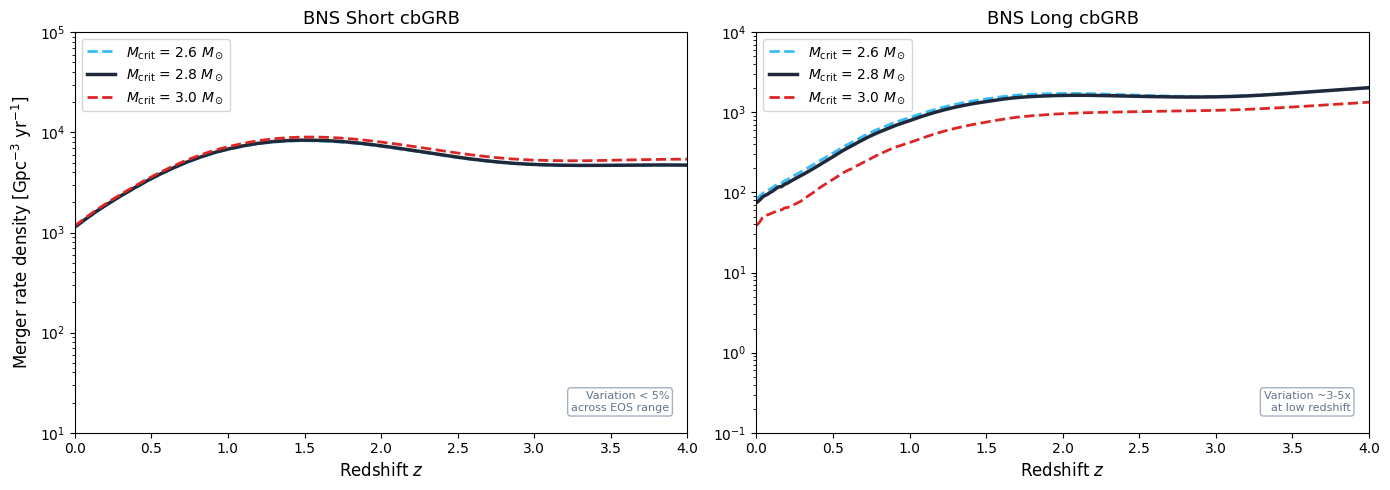

In [12]:
mcrit_colors = {2.6: '#38BDF8', 2.8: '#1E293B', 3.0: '#DC2626'}
mcrit_styles = {2.6: '--',         2.8: '-',      3.0: '--'}
rates_mcrit_short = {}
rates_mcrit_long  = {}

for Mc in [2.6, 2.8, 3.0]:
    s = (M_tot < Mc) | ((M_tot >= Mc) & (q < 1.2))
    l = (M_tot >= Mc) & (q >= 1.2)
    print(f'M_crit={Mc}: Short={s.sum():,} ({100*s.mean():.1f}%)  Long={l.sum():,} ({100*l.mean():.1f}%)')
    rates_mcrit_short[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[s], delay_BNS[s], w_BNS[s],
    )
    rates_mcrit_long[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[l], delay_BNS[l], w_BNS[l],
    )

# Independent y-axes so each panel uses its own data range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for Mc in [2.6, 2.8, 3.0]:
    c, ls = mcrit_colors[Mc], mcrit_styles[Mc]
    lw = 2.5 if Mc == 2.8 else 2
    axes[0].plot(redshifts, rates_mcrit_short[Mc], color=c, ls=ls, lw=lw,
                 label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')
    axes[1].plot(redshifts, rates_mcrit_long[Mc],  color=c, ls=ls, lw=lw,
                 label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')

for ax, title, ylims in zip(axes,
                             ['Short cbGRB', 'Long cbGRB'],
                             [(1e1, 1e5),    (1e-1, 1e4)]):
    ax.set_xlim(0, 4)
    ax.set_ylim(*ylims)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {title}', fontsize=13)
    ax.legend(fontsize=10, loc='upper left')
axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)

# Robustness annotations: bottom right of each panel
axes[0].text(0.97, 0.05, 'Variation < 5%\nacross EOS range',
             transform=axes[0].transAxes, fontsize=8, color='#64748B',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#94A3B8', alpha=0.85))
axes[1].text(0.97, 0.05, 'Variation ~3-5x\nat low redshift',
             transform=axes[1].transAxes, fontsize=8, color='#64748B',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#94A3B8', alpha=0.85))

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_mcrit_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5c. Model K vs Model A: Binary Physics Uncertainty

Model K uses a lower common envelope efficiency ($\alpha_{\rm CE} = 0.5$) vs the fiducial Model A ($\alpha_{\rm CE} = 1.0$).  
Comparing the full cosmic rates between models shows how sensitive the predicted GRB rates are  
to uncertain binary evolution physics, independent of the EOS or BH spin assumptions.

Both short and long cbGRB rates are compared, with the shaded band showing the model uncertainty range.

**Normalization note:** Both Model A and Model K use the same `meanMassEvolved` value (same primary mass range, IMF, and number of binaries per metallicity). If a future COMPAS dataset changes the simulation setup for Model K, this value must be re-derived.

Normalization check: Model A 233,137 DCOs | Model K 234,963 DCOs
Model K - Merging BNS: 234,963
Short cbGRB: 191,290  (81.4%)
Long  cbGRB: 43,673  (18.6%)
Computing Model K Short cbGRB (191,290 systems)...


  z=0: 1304.8  Gpc-3 yr-1
Computing Model K Long cbGRB (43,673 systems)...


  z=0: 200.6  Gpc-3 yr-1
Computing Model K All BNS (234,963 systems)...


  z=0: 1505.4  Gpc-3 yr-1


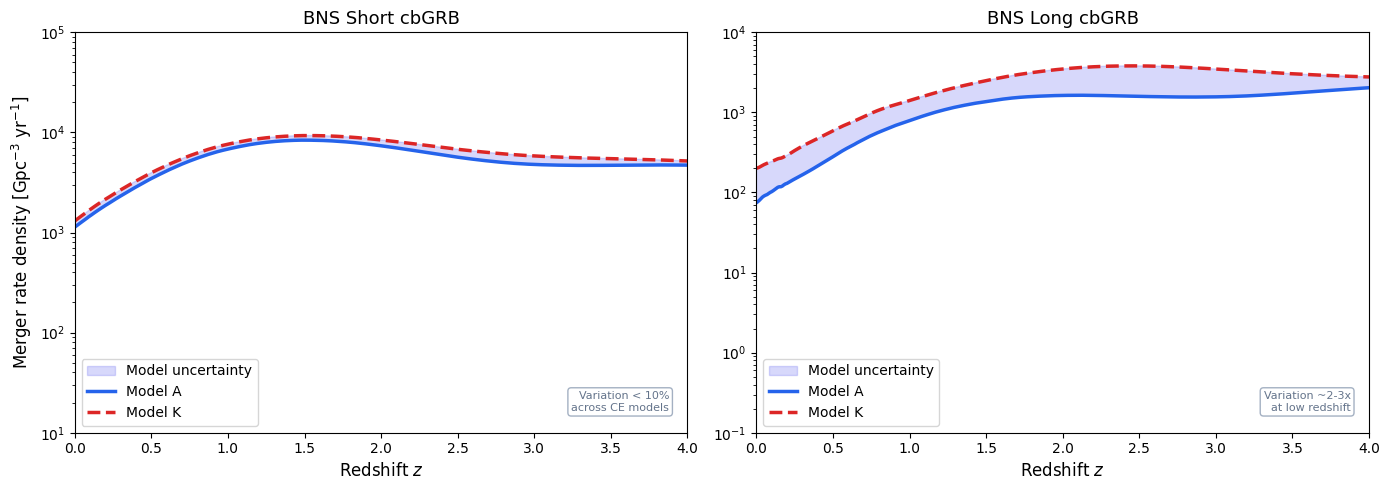

In [13]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'

# ── Model K normalization sanity check ────────────────────────────────────
# meanMassEvolved depends on the INITIAL binary sampling (IMF, mass range,
# N_sim), NOT on the number of surviving DCOs.  Both Model A and K use the
# same initial sampling, so meanMassEvolved is shared.
with h5.File(path_BNS, 'r') as _fA, h5.File(path_K, 'r') as _fK:
    _nA = _fA['doubleCompactObjects']['M1'].shape[0]
    _nK = _fK['doubleCompactObjects']['M1'].shape[0]
    print(f"Normalization check: Model A {_nA:,} DCOs | Model K {_nK:,} DCOs")
    if _nA != _nK:
        print(f"  WARNING: DCO counts differ ({_nA} vs {_nK}). This is expected "
              f"if CE efficiency changes the number of surviving binaries, but "
              f"meanMassEvolved is still shared (same initial sampling).")
    else:
        print("  OK: same DCO count, initial sampling confirmed identical.")

with h5.File(path_K, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1_K   = fDCO['M1'][...].squeeze()
    mass2_K   = fDCO['M2'][...].squeeze()
    weights_K = fDCO['weight'][...].squeeze()
    Z_K_all   = fDCO['Metallicity1'][...].squeeze()
    merges_K  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_K      = fDCO['tc'][...].squeeze()
    tform_K   = fDCO['tform'][...].squeeze()

mask_K  = (merges_K == 1)
M_tot_K = mass1_K[mask_K] + mass2_K[mask_K]
q_K     = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K = (M_tot_K < 2.8) | ((M_tot_K >= 2.8) & (q_K < 1.2))
long_K  = (M_tot_K >= 2.8) & (q_K >= 1.2)

delay_K = (tform_K + tc_K)[mask_K]
Z_K     = Z_K_all[mask_K]
w_K     = weights_K[mask_K]

print(f'Model K - Merging BNS: {mask_K.sum():,}')
print(f'Short cbGRB: {short_K.sum():,}  ({100*short_K.mean():.1f}%)')
print(f'Long  cbGRB: {long_K.sum():,}  ({100*long_K.mean():.1f}%)')

merger_rates_K = {}
for label, mask_grb in [('Short cbGRB', short_K),
                          ('Long cbGRB',  long_K),
                          ('All BNS',     np.ones(len(delay_K), dtype=bool))]:
    print(f'Computing Model K {label} ({mask_grb.sum():,} systems)...')
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_K[mask_grb], delay_K[mask_grb], w_K[mask_grb],
    )
    merger_rates_K[label] = rate
    print(f'  z=0: {rate[0]:.1f}  Gpc-3 yr-1')

# ---- Plot Model A vs Model K ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, label in zip([ax1, ax2], ['Short cbGRB', 'Long cbGRB']):
    rA = merger_rates_BNS[label]
    rK = merger_rates_K[label]
    # Uncertainty band beneath lines
    ax.fill_between(redshifts,
                    np.minimum(rA, rK), np.maximum(rA, rK),
                    alpha=0.25, color='#6366F1', label='Model uncertainty')
    ax.plot(redshifts, rA, color='#2563EB', lw=2.5, label='Model A')
    ax.plot(redshifts, rK, color='#DC2626',  lw=2.5, ls='--', label='Model K')
    ax.set_xlim(0, 4)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {label}', fontsize=13)
    ax.legend(fontsize=10, loc='lower left')
    pass  # annotations set per-panel below

# Per-panel annotations (short: robust; long: sensitive to CE efficiency)
ax1.text(0.97, 0.05, 'Variation < 10%\nacross CE models',
         transform=ax1.transAxes, fontsize=8, color='#64748B',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#94A3B8', alpha=0.85))
ax2.text(0.97, 0.05, 'Variation ~2-3x\nat low redshift',
         transform=ax2.transAxes, fontsize=8, color='#64748B',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#94A3B8', alpha=0.85))

# Set ylim AFTER all plotting to prevent autoscale override
ax1.set_ylim(1e1, 1e5)
ax2.set_ylim(1e-1, 1e4)

ax1.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_model_ak.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 8. Combined BNS + BHNS cbGRB Rate Overview

Summary plot comparing all cbGRB-producing channels from both BNS and BHNS
populations on a single axis, using the Gottlieb et al. (2023) hybrid classification.

**BNS channels** (by $M_\mathrm{tot}$ and mass ratio $q$):
- **Type I short cbGRB**: $M_\mathrm{tot} < M_\mathrm{crit}$, producing an HMNS remnant.
- **Type II short cbGRB**: $M_\mathrm{tot} \geq M_\mathrm{crit}$, $q < 1.2$, producing a BH + light disk.
- **Long cbGRB**: $M_\mathrm{tot} \geq M_\mathrm{crit}$, $q \geq 1.2$, producing a BH + massive disk (Rastinejad et al. 2025).

**BHNS channels** (by disk mass, Foucart et al. 2018):
- At the fiducial $a_\mathrm{BH} = 0.5$, the BHNS **long cbGRB** channel is entirely
  empty (0 systems) because there is insufficient spin for tidal disruption to
  produce massive disks (Foucart 2012). The **short cbGRB** channel contains
  $\sim$14 k systems but contributes only $\sim$9% of the BHNS total rate at $z=0$.

COMPAS Model A (pessimistic CE), $R_\mathrm{NS} = 11\,$km, MSSFR from Neijssel et al. (2019).

Combined BNS + BHNS cbGRB rates (Model A, a_BH=0.5, R_NS=11 km):
  BNS  Type I sGRB  z=0: 1,085.6  Gpc⁻³ yr⁻¹
  BNS  Type II sGRB z=0: 46.0  Gpc⁻³ yr⁻¹
  BNS  Long cbGRB   z=0: 74.5  Gpc⁻³ yr⁻¹
  BNS  total         z=0: 1,206.1  Gpc⁻³ yr⁻¹
  BHNS sGRB (a=0.5)  z=0: 221.8  (9.9% of BHNS total)
  BHNS lGRB (a=0.5)  z=0: 0.0  (0 systems)
  BHNS total         z=0: 2,246.6  Gpc⁻³ yr⁻¹


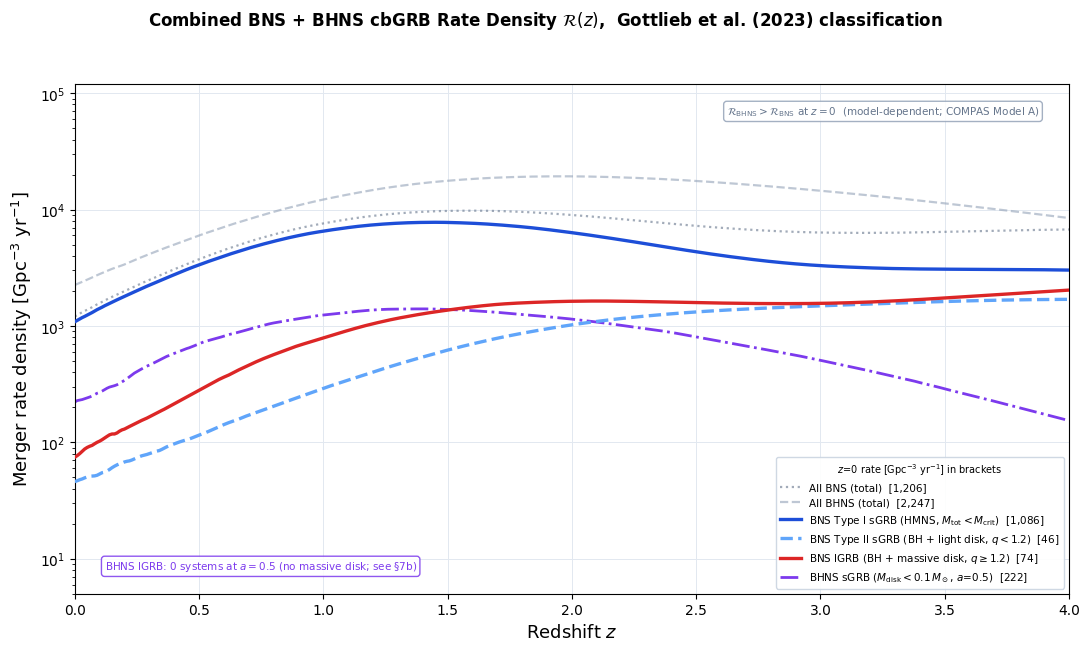

In [14]:
r_bns_all   = merger_rates_BNS['All BNS']
r_bns_s1    = merger_rates_BNS['Short cbGRB (Type I)']
r_bns_s2    = merger_rates_BNS['Short cbGRB (Type II)']
r_bns_long  = merger_rates_BNS['Long cbGRB']
r_bhns_all  = merger_rates_BHNS['All BHNS']
r_bhns_sgrb = merger_rates_BHNS['Short cbGRB (a=0.5)']
r_bhns_lgrb = merger_rates_BHNS['Long cbGRB (a=0.5)']
iz0 = 0

print("Combined BNS + BHNS cbGRB rates (Model A, a_BH=0.5, R_NS=11 km):")
print(f"  BNS  Type I sGRB  z=0: {r_bns_s1[iz0]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")
print(f"  BNS  Type II sGRB z=0: {r_bns_s2[iz0]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")
print(f"  BNS  Long cbGRB   z=0: {r_bns_long[iz0]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")
print(f"  BNS  total         z=0: {r_bns_all[iz0]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")
sgrb_frac = r_bhns_sgrb[iz0] / r_bhns_all[iz0] * 100 if r_bhns_all[iz0] > 0 else 0
print(f"  BHNS sGRB (a=0.5)  z=0: {r_bhns_sgrb[iz0]:,.1f}  ({sgrb_frac:.1f}% of BHNS total)")
print(f"  BHNS lGRB (a=0.5)  z=0: {r_bhns_lgrb[iz0]:.1f}  (0 systems)")
print(f"  BHNS total         z=0: {r_bhns_all[iz0]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")

def _rate_label(val):
    return f'{val:,.0f}' if val >= 1 else f'{val:.2f}'

fig, ax = plt.subplots(figsize=(11, 6.5))

# ---- Totals (gray, background reference) ----
ax.plot(redshifts, r_bns_all,
        color='#64748B', lw=1.6, ls=':', alpha=0.6, zorder=1,
        label=f'All BNS (total)  [{_rate_label(r_bns_all[iz0])}]')
ax.plot(redshifts, r_bhns_all,
        color='#94A3B8', lw=1.6, ls='--', alpha=0.6, zorder=1,
        label=f'All BHNS (total)  [{_rate_label(r_bhns_all[iz0])}]')

# ---- BNS channels ----
ax.plot(redshifts, r_bns_s1,
        color='#1D4ED8', lw=2.4, ls='-', zorder=3,
        label=r'BNS Type I sGRB (HMNS, $M_\mathrm{tot} < M_\mathrm{crit}$)'
              f'  [{_rate_label(r_bns_s1[iz0])}]')
ax.plot(redshifts, r_bns_s2,
        color='#60A5FA', lw=2.4, ls='--', zorder=3,
        label=r'BNS Type II sGRB (BH + light disk, $q < 1.2$)'
              f'  [{_rate_label(r_bns_s2[iz0])}]')
ax.plot(redshifts, r_bns_long,
        color='#DC2626', lw=2.4, ls='-', zorder=3,
        label=r'BNS lGRB (BH + massive disk, $q \geq 1.2$)'
              f'  [{_rate_label(r_bns_long[iz0])}]')

# ---- BHNS sGRB channel (a=0.5) ----
if r_bhns_sgrb[iz0] > 0:
    ax.plot(redshifts, r_bhns_sgrb,
            color='#7C3AED', lw=2.0, ls='-.', zorder=2,
            label=r'BHNS sGRB ($M_\mathrm{disk} < 0.1\,M_\odot$, $a\!=\!0.5$)'
                  f'  [{_rate_label(r_bhns_sgrb[iz0])}]')

# ---- Grid ----
ax.grid(True, which='major', color='#E2E8F0', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# ---- Axis limits ----
ax.set_xlim(0, 4)
ax.set_ylim(5, 1.2e5)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)

# ---- Annotation: BHNS lGRB vanishes at a=0.5 (top-left, away from legend) ----
ax.text(0.03, 0.04,
        r'BHNS lGRB: 0 systems at $a = 0.5$'
        ' (no massive disk; see \u00a77b)',
        transform=ax.transAxes, fontsize=7.5, color='#7C3AED',
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#7C3AED', alpha=0.85))

# ---- Flag if BHNS total exceeds BNS total ----
if r_bhns_all[iz0] > r_bns_all[iz0]:
    ax.text(0.97, 0.96,
            r'$\mathcal{R}_\mathrm{BHNS} > \mathcal{R}_\mathrm{BNS}$ at $z=0$'
            '  (model-dependent; COMPAS Model A)',
            transform=ax.transAxes, fontsize=7.5, color='#64748B',
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#94A3B8', alpha=0.85))

# ---- Legend (z=0 rates embedded in labels, so no separate annotations needed) ----
leg = ax.legend(fontsize=7.5, loc='lower right', framealpha=0.92,
                edgecolor='#CBD5E1', fancybox=True,
                title=r'$z\!=\!0$ rate [Gpc$^{-3}$ yr$^{-1}$] in brackets',
                title_fontsize=7)

# ---- Suptitle ----
fig.suptitle(
    r'Combined BNS + BHNS cbGRB Rate Density $\mathcal{R}(z)$'
    ',  Gottlieb et al. (2023) classification',
    fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_combined_bns_bhns.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 9. Unified Figure 2 Rate Plot: All cbGRB Classes

Two-panel comparison of all Gottlieb et al. (2023) cbGRB channels across cosmic time (COMPAS Model A, MSSFR from Neijssel et al. 2019).

**Left panel, BNS channels** (classified by $M_\mathrm{tot}$ and mass ratio $q$):
- **Type I sGRB** (HMNS): $M_\mathrm{tot} < M_\mathrm{crit} = 2.8\,M_\odot$
- **Type II sGRB** (BH + light disk): $M_\mathrm{tot} \geq M_\mathrm{crit}$, $q < 1.2$
- **lGRB** (BH + massive disk): $M_\mathrm{tot} \geq M_\mathrm{crit}$, $q \geq 1.2$, linked to asymmetric mergers (Rastinejad et al. 2025)

**Right panel, BHNS channels** (classified by disk mass, Foucart et al. 2018, $a_\mathrm{BH} = 0.5$):
- **sGRB**: $0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$ (~9% of BHNS total)
- **lGRB**: $M_\mathrm{disk} \geq 0.1\,M_\odot$; **zero systems** at $a = 0.5$ (Foucart 2012: massive disks require $\chi_\mathrm{BH} \gtrsim 0.7$ to $0.9$ for $Q \sim 5$ to $10$, $R_\mathrm{NS} = 11\,$km)
- ~91% of BHNS mergers at this spin are "dark" (no tidal disruption, direct plunge into BH)

Unified two-panel rates (Model A, a_BH=0.5, R_NS=11 km):
  BNS  Type I   z=0: 1,086
  BNS  Type II  z=0: 46
  BNS  lGRB     z=0: 74
  BNS  total    z=0: 1,206
  BHNS sGRB     z=0: 222  (9.9% of BHNS)
  BHNS lGRB     z=0: 0.0  (peak=0.0)
  BHNS total    z=0: 2,247
  BHNS dark     z=0: 90% (no tidal disruption)


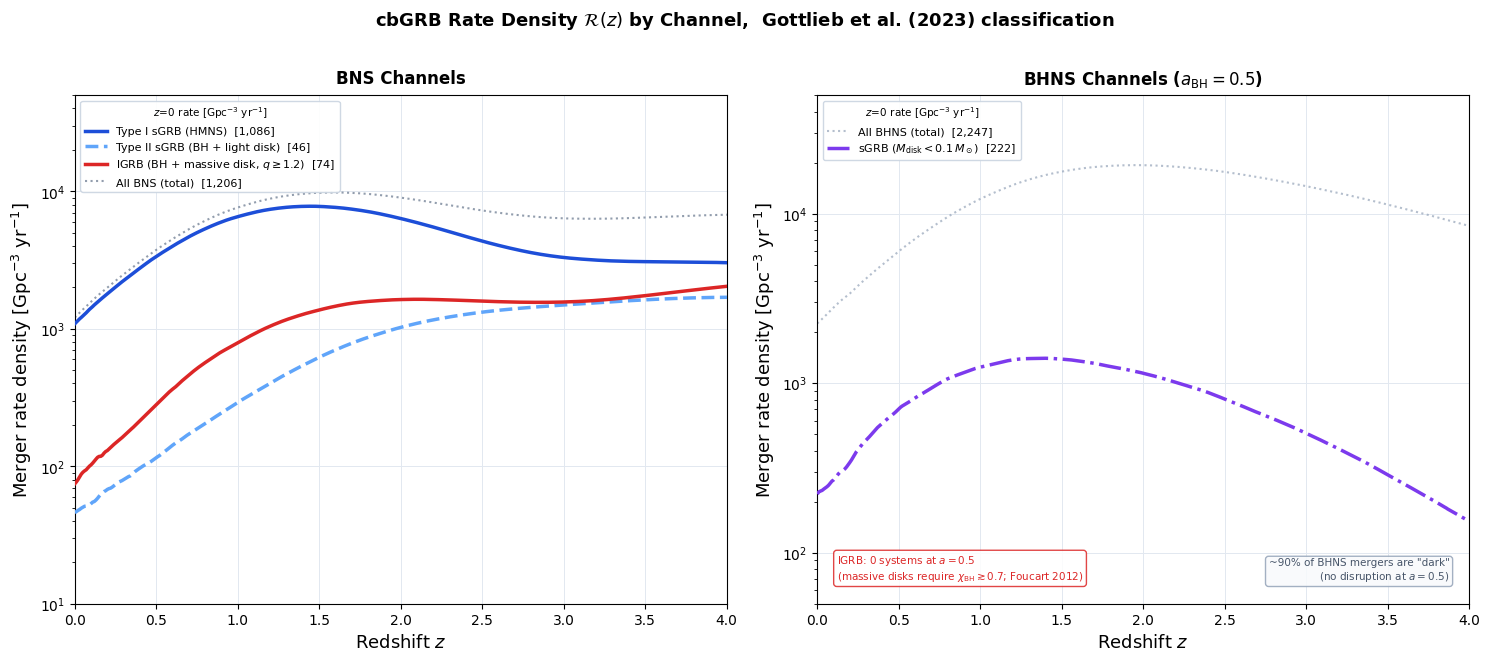

In [15]:
bhns_sgrb_arr  = merger_rates_BHNS['Short cbGRB (a=0.5)']
bhns_lgrb_arr  = merger_rates_BHNS['Long cbGRB (a=0.5)']
bhns_total_arr = merger_rates_BHNS['All BHNS']
bns_s1   = merger_rates_BNS['Short cbGRB (Type I)']
bns_s2   = merger_rates_BNS['Short cbGRB (Type II)']
bns_long = merger_rates_BNS['Long cbGRB']
bns_all  = merger_rates_BNS['All BNS']
iz0 = 0

sgrb_frac = bhns_sgrb_arr[iz0] / bhns_total_arr[iz0] if bhns_total_arr[iz0] > 0 else 0.0
lgrb_peak = bhns_lgrb_arr.max()
dark_frac = 1.0 - (sgrb_frac + (bhns_lgrb_arr[iz0] / bhns_total_arr[iz0] if bhns_total_arr[iz0] > 0 else 0))

print("Unified two-panel rates (Model A, a_BH=0.5, R_NS=11 km):")
print(f"  BNS  Type I   z=0: {bns_s1[iz0]:,.0f}")
print(f"  BNS  Type II  z=0: {bns_s2[iz0]:,.0f}")
print(f"  BNS  lGRB     z=0: {bns_long[iz0]:,.0f}")
print(f"  BNS  total    z=0: {bns_all[iz0]:,.0f}")
print(f"  BHNS sGRB     z=0: {bhns_sgrb_arr[iz0]:,.0f}  ({sgrb_frac*100:.1f}% of BHNS)")
print(f"  BHNS lGRB     z=0: {bhns_lgrb_arr[iz0]:.1f}  (peak={lgrb_peak:.1f})")
print(f"  BHNS total    z=0: {bhns_total_arr[iz0]:,.0f}")
print(f"  BHNS dark     z=0: {dark_frac*100:.0f}% (no tidal disruption)")

def _rl(v):
    return f'{v:,.0f}' if v >= 1 else f'{v:.2f}'

fig, (ax_bns, ax_bhns) = plt.subplots(1, 2, figsize=(15, 6.5))

# ===== Left panel: BNS channels =====
ax_bns.plot(redshifts, bns_s1,
            color='#1D4ED8', lw=2.5, ls='-', zorder=3,
            label=r'Type I sGRB (HMNS)  [' + _rl(bns_s1[iz0]) + ']')
ax_bns.plot(redshifts, bns_s2,
            color='#60A5FA', lw=2.5, ls='--', zorder=3,
            label=r'Type II sGRB (BH + light disk)  [' + _rl(bns_s2[iz0]) + ']')
ax_bns.plot(redshifts, bns_long,
            color='#DC2626', lw=2.5, ls='-', zorder=3,
            label=r'lGRB (BH + massive disk, $q \geq 1.2$)  [' + _rl(bns_long[iz0]) + ']')
ax_bns.plot(redshifts, bns_all,
            color='#64748B', lw=1.5, ls=':', alpha=0.7, zorder=1,
            label=f'All BNS (total)  [{_rl(bns_all[iz0])}]')

ax_bns.set_title('BNS Channels', fontsize=12, fontweight='bold', pad=8)
ax_bns.grid(True, which='major', color='#E2E8F0', linewidth=0.7, zorder=0)
ax_bns.set_axisbelow(True)
ax_bns.set_xlim(0, 4)
ax_bns.set_ylim(10, 5e4)
ax_bns.set_yscale('log')
ax_bns.set_xlabel('Redshift $z$', fontsize=13)
ax_bns.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax_bns.legend(fontsize=8, loc='upper left', framealpha=0.92, edgecolor='#CBD5E1',
              title=r'$z\!=\!0$ rate [Gpc$^{-3}$ yr$^{-1}$]', title_fontsize=7.5)

# ===== Right panel: BHNS channels (a=0.5) =====
ax_bhns.plot(redshifts, bhns_total_arr,
             color='#94A3B8', lw=1.5, ls=':', alpha=0.7, zorder=1,
             label=f'All BHNS (total)  [{_rl(bhns_total_arr[iz0])}]')

if sgrb_frac > 0.01:
    ax_bhns.plot(redshifts, bhns_sgrb_arr,
                 color='#7C3AED', lw=2.5, ls='-.', zorder=3,
                 label=r'sGRB ($M_\mathrm{disk} < 0.1\,M_\odot$)  ['
                       + _rl(bhns_sgrb_arr[iz0]) + ']')

if lgrb_peak > 1.0:
    ax_bhns.plot(redshifts, bhns_lgrb_arr,
                 color='#DC2626', lw=2.5, ls='-', zorder=3,
                 label=r'lGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$)  ['
                       + _rl(bhns_lgrb_arr[iz0]) + ']')
else:
    ax_bhns.text(0.03, 0.04,
                 r'lGRB: 0 systems at $a = 0.5$'
                 '\n(massive disks require '
                 r'$\chi_\mathrm{BH} \gtrsim 0.7$'
                 '; Foucart 2012)',
                 transform=ax_bhns.transAxes, fontsize=7.5, color='#DC2626',
                 va='bottom', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#DC2626', alpha=0.85))

if sgrb_frac <= 0.01:
    ax_bhns.text(0.97, 0.97,
                 f'sGRB: {sgrb_frac*100:.1f}% of total (not plotted)',
                 transform=ax_bhns.transAxes, fontsize=8, color='#7C3AED',
                 ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#7C3AED', alpha=0.8))

ax_bhns.text(0.97, 0.04,
             f'~{dark_frac*100:.0f}% of BHNS mergers are "dark"\n'
             r'(no disruption at $a = 0.5$)',
             transform=ax_bhns.transAxes, fontsize=7.5, color='#475569',
             va='bottom', ha='right',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#F8FAFC',
                       edgecolor='#94A3B8', alpha=0.85))

ax_bhns.set_title(r'BHNS Channels ($a_\mathrm{BH} = 0.5$)', fontsize=12,
                   fontweight='bold', pad=8)
ax_bhns.grid(True, which='major', color='#E2E8F0', linewidth=0.7, zorder=0)
ax_bhns.set_axisbelow(True)
ax_bhns.set_xlim(0, 4)
ax_bhns.set_ylim(50, 5e4)
ax_bhns.set_yscale('log')
ax_bhns.set_xlabel('Redshift $z$', fontsize=13)
ax_bhns.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax_bhns.legend(fontsize=8, loc='upper left', framealpha=0.92, edgecolor='#CBD5E1',
               title=r'$z\!=\!0$ rate [Gpc$^{-3}$ yr$^{-1}$]', title_fontsize=7.5)

fig.suptitle(
    r'cbGRB Rate Density $\mathcal{R}(z)$ by Channel'
    ',  Gottlieb et al. (2023) classification',
    fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_figure2_unified.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10. Mass Distributions at Redshift Slices

How does the merging BNS mass distribution shift with cosmic time? At high redshift, low-metallicity star formation dominates, which can change the typical NS mass and shift the long vs. short cbGRB balance (Broekgaarden et al. 2022, Fig. 6). Each binary is weighted by its contribution to the merger rate at a specific target redshift.

**Top row:** $M_1$ vs $M_2$ scatter (top 40% rate contributors) with Gottlieb classification boundaries ($M_\mathrm{crit} = 2.8\,M_\odot$, $q = 1.2$). ECSN remnants cluster at $M_2 \approx 1.26\,M_\odot$ (Neijssel et al. 2019). Type I short cbGRBs (HMNS, dark blue) lie below the $M_\mathrm{crit}$ diagonal; Type II short cbGRBs (BH + light disk, light blue) lie above it but below the $q = 1.2$ line; long cbGRBs (red) occupy the asymmetric corner ($q \geq 1.2$, Rastinejad et al. 2025).

**Bottom row:** $M_\mathrm{tot}$ histograms weighted by rate contribution, normalized per $M_\odot$ bin width.

In [16]:
def per_system_rate_weights(z_target, redshifts, times, time_first_SF,
                             n_formed, dPdlogZ, metallicities, p_draw,
                             COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Per-system contribution to the merger rate at z_target.
    Mirrors compute_merger_rate but returns an array of individual weights
    instead of summing them, so histograms can be weighted by rate contribution.
    """
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)

    j_target = np.argmin(np.abs(redshifts - z_target))
    t_merge  = times[j_target]

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)
    t_min  = max(time_first_SF, times.min())

    out    = np.zeros(len(COMPAS_weights))
    t_form = t_merge - COMPAS_delay_times
    valid  = t_form >= t_min

    if valid.any():
        z_form     = times_to_z(t_form[valid])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int),
                             0, len(redshifts) - 1)
        out[valid] = (n_formed[z_form_idx]
                      * dPdlogZ[z_form_idx, Z_bins[valid]]
                      / p_draw
                      * COMPAS_weights[valid])
    return out


/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/3598586524.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


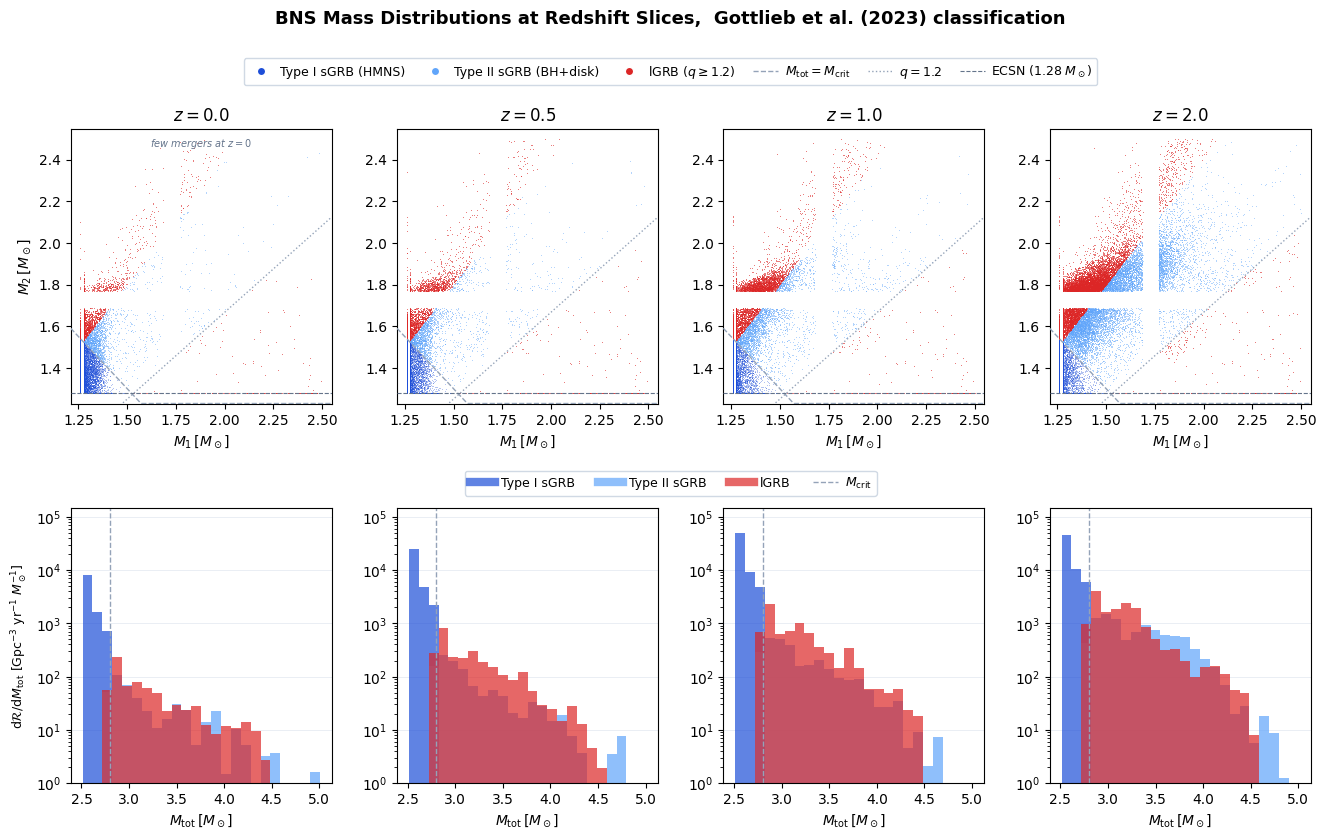

In [17]:
from matplotlib.lines import Line2D

M1_m = mass1[mask_BNS]
M2_m = mass2[mask_BNS]

z_slices = [0.0, 0.5, 1.0, 2.0]

_m1_pad = 0.04 * (M1_m.max() - M1_m.min())
_m2_pad = 0.04 * (M2_m.max() - M2_m.min())
m1_xlim  = (M1_m.min() - _m1_pad, M1_m.max() + _m1_pad)
m2_ylim  = (M2_m.min() - _m2_pad, M2_m.max() + _m2_pad)
bins_mtot = np.linspace(M_tot.min() * 0.99, M_tot.max() * 1.01, 25)
bin_width = bins_mtot[1] - bins_mtot[0]
ecsn_mass = M2_m.min()

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5),
                         gridspec_kw={'hspace': 0.38, 'wspace': 0.25})

_hist_ymaxes = []

for col, z_s in enumerate(z_slices):
    w = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )

    # === Top row: M1 vs M2 scatter (top 40% rate contributors) ===
    ax = axes[0, col]
    w_thresh = np.percentile(w[w > 0], 60) if (w > 0).any() else 0.0
    vis = w >= w_thresh

    ax.scatter(M1_m[vis & short_BNS_I], M2_m[vis & short_BNS_I],
               s=0.4, c='#1D4ED8', alpha=0.30, linewidths=0, zorder=1)
    ax.scatter(M1_m[vis & short_BNS_II], M2_m[vis & short_BNS_II],
               s=0.4, c='#60A5FA', alpha=0.45, linewidths=0, zorder=1)
    ax.scatter(M1_m[vis & long_BNS], M2_m[vis & long_BNS],
               s=0.4, c='#DC2626', alpha=0.60, linewidths=0, zorder=2)

    m_vals = np.linspace(m1_xlim[0], m1_xlim[1], 200)
    m_mcrit = np.clip(2.8 - m_vals, m2_ylim[0], m2_ylim[1])
    ax.plot(m_vals, m_mcrit, color='#94A3B8', lw=1, ls='--', zorder=3)
    ax.plot(m_vals, m_vals / 1.2, color='#94A3B8', lw=1, ls=':', zorder=3)
    ax.axhline(ecsn_mass, color='#64748B', lw=0.8, ls='--', zorder=3)

    ax.set_xlim(*m1_xlim)
    ax.set_ylim(*m2_ylim)
    ax.set_title(f'$z = {z_s}$', fontsize=12, fontweight='bold')
    if z_s == 0.0:
        ax.text(0.50, 0.97, 'few mergers at $z=0$',
                transform=ax.transAxes, fontsize=7, color='#64748B',
                ha='center', va='top', style='italic')
    ax.set_xlabel(r'$M_1\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$M_2\,[M_\odot]$', fontsize=10)

    # === Bottom row: M_tot histogram (normalized per M_sun) ===
    ax2 = axes[1, col]
    n_s1, _, _ = ax2.hist(M_tot[short_BNS_I], bins=bins_mtot,
                           weights=w[short_BNS_I] / bin_width,
                           color='#1D4ED8', alpha=0.70)
    n_s2, _, _ = ax2.hist(M_tot[short_BNS_II], bins=bins_mtot,
                           weights=w[short_BNS_II] / bin_width,
                           color='#60A5FA', alpha=0.70)
    n_ln, _, _ = ax2.hist(M_tot[long_BNS], bins=bins_mtot,
                           weights=w[long_BNS] / bin_width,
                           color='#DC2626', alpha=0.70)
    _hist_ymaxes.append(max(n_s1.max(), n_s2.max(), n_ln.max()))
    ax2.axvline(2.8, color='#94A3B8', ls='--', lw=1)
    ax2.set_yscale('log')
    ax2.grid(True, which='major', axis='y', color='#E2E8F0', lw=0.5, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_xlabel(r'$M_\mathrm{tot}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}M_\mathrm{tot}$'
                        r' [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]', fontsize=9)

_ymax = max(_hist_ymaxes) * 3
_ymin = 1.0
for ax2 in axes[1]:
    ax2.set_ylim(_ymin, _ymax)

scatter_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D4ED8',
           markersize=6, label='Type I sGRB (HMNS)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#60A5FA',
           markersize=6, label='Type II sGRB (BH+disk)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#DC2626',
           markersize=6, label=r'lGRB ($q \geq 1.2$)'),
    Line2D([0],[0], color='#94A3B8', lw=1, ls='--',
           label=r'$M_\mathrm{tot} = M_\mathrm{crit}$'),
    Line2D([0],[0], color='#94A3B8', lw=1, ls=':',
           label=r'$q = 1.2$'),
    Line2D([0],[0], color='#64748B', lw=0.8, ls='--',
           label=f'ECSN ({ecsn_mass:.2f} $M_\\odot$)'),
]
fig.legend(handles=scatter_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.97), ncol=6, fontsize=9,
           framealpha=0.9, edgecolor='#CBD5E1', columnspacing=1.4,
           handletextpad=0.5)

hist_handles = [
    Line2D([0],[0], color='#1D4ED8', lw=6, alpha=0.70, label='Type I sGRB'),
    Line2D([0],[0], color='#60A5FA', lw=6, alpha=0.70, label='Type II sGRB'),
    Line2D([0],[0], color='#DC2626', lw=6, alpha=0.70, label='lGRB'),
    Line2D([0],[0], color='#94A3B8', lw=1, ls='--', label=r'$M_\mathrm{crit}$'),
]
fig.legend(handles=hist_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.485), ncol=4, fontsize=9,
           framealpha=0.9, edgecolor='#CBD5E1', columnspacing=1.8,
           handletextpad=0.5)

fig.suptitle('BNS Mass Distributions at Redshift Slices'
             ',  Gottlieb et al. (2023) classification',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_mass_dist_redshift_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10b. BNS + BHNS Gottlieb Classification Plane: $q$ vs $M_\mathrm{tot}$ at Redshift Slices

Recreates the Gottlieb et al. (2023) Fig. 2 classification diagram using the COMPAS population, weighted by rate contribution at each redshift.

**Top row (full view, log scale):** Both BNS and BHNS populations in the $q$ vs $M_\mathrm{tot}$ plane.
- BNS systems cluster at $M_\mathrm{tot} \sim 2.5$ to $5\,M_\odot$, $q \sim 1$ to $1.5$, classified by $M_\mathrm{crit}$ and $q_\mathrm{thresh}$.
- BHNS systems sit at higher $M_\mathrm{tot}$ and $q$, classified by Foucart disk mass ($a = 0.5$): **sGRB** ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$, ~9% of BHNS), **no GRB** (~91%).
- At $a = 0.5$, BHNS lGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$) has zero systems (Foucart 2012).

**Bottom row (BNS zoom, linear scale):** Zoomed view of the three BNS outcomes: Short I (HMNS), Short II (BH + light disk), Long cbGRB (BH + massive disk, $q \geq 1.2$; Rastinejad et al. 2025).

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/1885023611.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


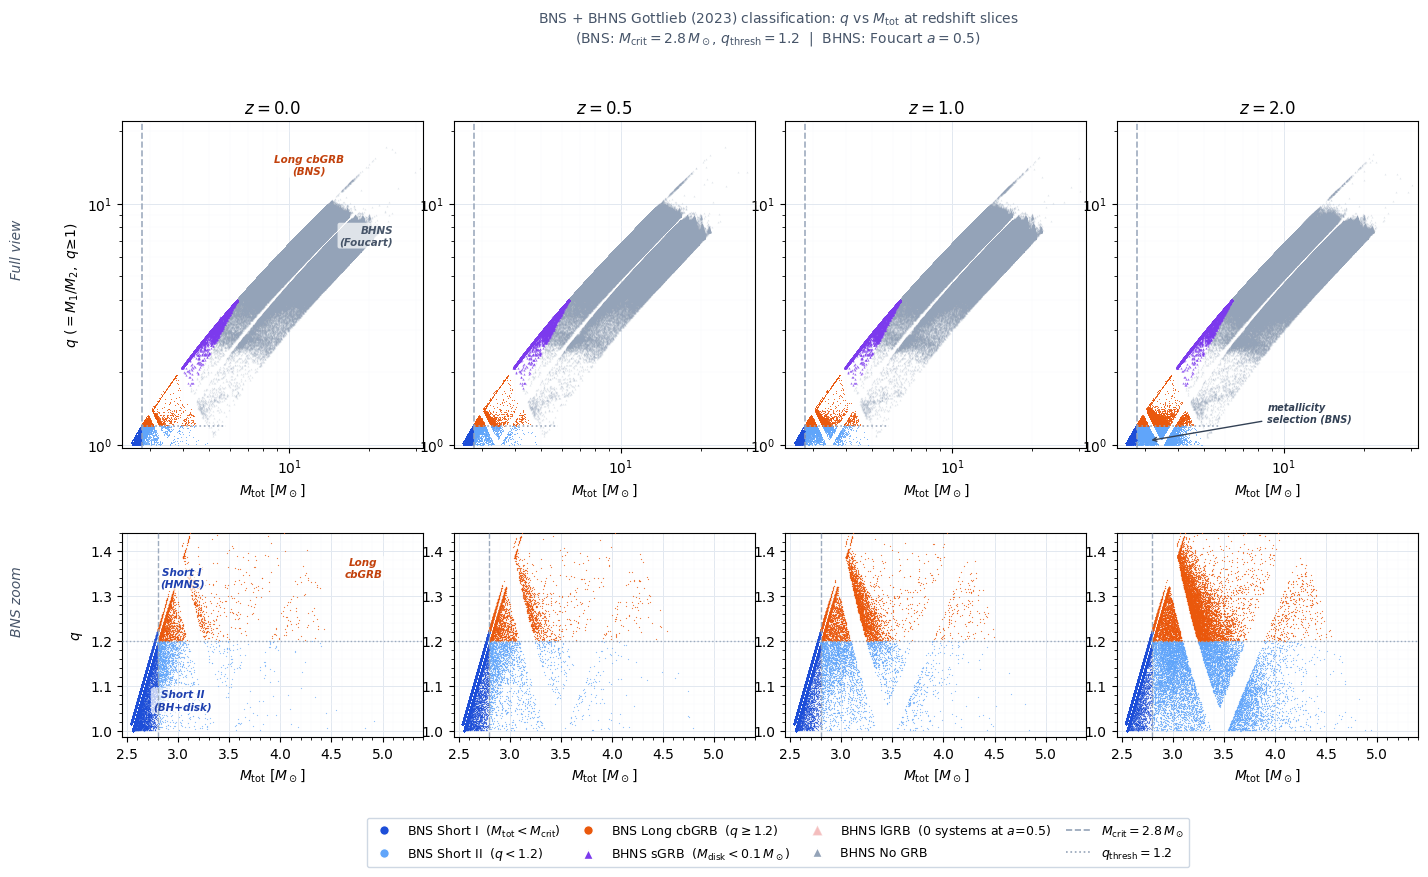

In [18]:
from matplotlib.lines import Line2D

M_crit   = 2.8
q_thresh = 1.2
z_slices = [0.0, 0.5, 1.0, 2.0]

q_BHNS     = BH / NS
M_tot_BHNS = BH + NS

# Axis limits
mt_xlim  = (2.35, 32)       # full view (log)
q_ylim   = (0.97, 22)
bns_xlim = (2.45, 5.4)      # BNS zoom (linear)
bns_ylim = (0.985, 1.44)
_bns_mt_max = 5.8

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                          gridspec_kw={'hspace': 0.32, 'wspace': 0.10,
                                       'height_ratios': [1.6, 1]})
fig.suptitle(r'BNS + BHNS Gottlieb (2023) classification: $q$ vs $M_\mathrm{tot}$ at redshift slices'
             '\n'
             r'(BNS: $M_\mathrm{crit}=2.8\,M_\odot$, $q_\mathrm{thresh}=1.2$  |  BHNS: Foucart $a=0.5$)',
             fontsize=10, color='#475569', y=1.02)

for col, z_s in enumerate(z_slices):

    # ── rate weights ──────────────────────────────────────────────────────
    w_bns = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )
    w_bhns = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS, delay_BHNS, w_BHNS,
    )
    w_t_bns  = np.percentile(w_bns[w_bns > 0],   60) if (w_bns  > 0).any() else 0.0
    w_t_bhns = np.percentile(w_bhns[w_bhns > 0], 60) if (w_bhns > 0).any() else 0.0
    vis_bns  = w_bns  >= w_t_bns
    vis_bhns = w_bhns >= w_t_bhns

    # ── TOP ROW: full BNS + BHNS view (log scale) ─────────────────────────
    ax = axes[0, col]
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.axvline(M_crit, color='#94A3B8', lw=1.2, ls='--', zorder=4, alpha=0.9)
    ax.plot([M_crit, _bns_mt_max], [q_thresh, q_thresh],
            color='#94A3B8', lw=1.2, ls=':', zorder=4, alpha=0.9)

    ax.scatter(M_tot[vis_bns & short_BNS_I],  q[vis_bns & short_BNS_I],
               s=0.5, c='#1D4ED8', alpha=0.60, linewidths=0, zorder=2, marker='o')
    ax.scatter(M_tot[vis_bns & short_BNS_II], q[vis_bns & short_BNS_II],
               s=0.5, c='#60A5FA', alpha=0.70, linewidths=0, zorder=2, marker='o')
    ax.scatter(M_tot[vis_bns & long_BNS],     q[vis_bns & long_BNS],
               s=0.5, c='#EA580C', alpha=0.80, linewidths=0, zorder=3, marker='o')
    ax.scatter(M_tot_BHNS[vis_bhns & no_BHNS],   q_BHNS[vis_bhns & no_BHNS],
               s=2.0, c='#94A3B8', alpha=0.25, linewidths=0, zorder=2, marker='^')
    ax.scatter(M_tot_BHNS[vis_bhns & short_BHNS], q_BHNS[vis_bhns & short_BHNS],
               s=2.5, c='#7C3AED', alpha=0.70, linewidths=0, zorder=3, marker='^')
    if long_BHNS.any():
        ax.scatter(M_tot_BHNS[vis_bhns & long_BHNS], q_BHNS[vis_bhns & long_BHNS],
                   s=2.5, c='#DC2626', alpha=0.60, linewidths=0, zorder=3, marker='^')

    ax.grid(which='major', color='#E2E8F0', lw=0.7, ls='-', zorder=1)
    ax.grid(which='minor', color='#F8FAFC', lw=0.3, ls='-', zorder=1)
    ax.set_axisbelow(True)
    ax.set_xlim(*mt_xlim)
    ax.set_ylim(*q_ylim)
    ax.set_title(f'$z = {z_s}$', fontsize=12)
    ax.set_xlabel(r'$M_\mathrm{tot}\ [M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$q\ (= M_1/M_2,\ q\!\geq\!1)$', fontsize=10)
        ax.text(0.62, 0.90, 'Long cbGRB\n(BNS)', transform=ax.transAxes,
                fontsize=7.5, color='#C2410C', ha='center', va='top',
                style='italic', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))
        ax.text(0.90, 0.65, 'BHNS\n(Foucart)', transform=ax.transAxes,
                fontsize=7.5, color='#475569', ha='right', va='center',
                style='italic', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

    # Metallicity annotation on z=2.0 top panel
    if col == 3:
        ax.annotate('metallicity\nselection (BNS)',
                    xy=(3.1, 1.04), xycoords='data',
                    xytext=(0.50, 0.08), textcoords='axes fraction',
                    fontsize=7, color='#334155', style='italic', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#334155', lw=1.0))

    # ── BOTTOM ROW: BNS zoom (linear scale) ───────────────────────────────
    ax2 = axes[1, col]

    ax2.axvline(M_crit,   color='#94A3B8', lw=1.0, ls='--', zorder=4, alpha=0.9)
    ax2.axhline(q_thresh, color='#94A3B8', lw=1.0, ls=':', zorder=4, alpha=0.9)

    ax2.scatter(M_tot[vis_bns & short_BNS_I],  q[vis_bns & short_BNS_I],
                s=0.8, c='#1D4ED8', alpha=0.60, linewidths=0, zorder=2)
    ax2.scatter(M_tot[vis_bns & short_BNS_II], q[vis_bns & short_BNS_II],
                s=0.8, c='#60A5FA', alpha=0.70, linewidths=0, zorder=2)
    ax2.scatter(M_tot[vis_bns & long_BNS],     q[vis_bns & long_BNS],
                s=0.8, c='#EA580C', alpha=0.80, linewidths=0, zorder=3)

    ax2.grid(which='major', color='#E2E8F0', lw=0.7, ls='-', zorder=1)
    ax2.grid(which='minor', color='#F8FAFC', lw=0.3, ls='-', zorder=1)
    ax2.minorticks_on()
    ax2.set_axisbelow(True)
    ax2.set_xlim(*bns_xlim)
    ax2.set_ylim(*bns_ylim)
    ax2.set_xlabel(r'$M_\mathrm{tot}\ [M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'$q$', fontsize=10)
        _bbox = dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7)
        ax2.text(0.20, 0.78, 'Short I\n(HMNS)', transform=ax2.transAxes,
                 fontsize=7.5, color='#1E40AF', ha='center', va='center',
                 style='italic', fontweight='bold', bbox=_bbox)
        ax2.text(0.20, 0.18, 'Short II\n(BH+disk)', transform=ax2.transAxes,
                 fontsize=7.5, color='#1E40AF', ha='center', va='center',
                 style='italic', fontweight='bold', bbox=_bbox)
        ax2.text(0.80, 0.88, 'Long\ncbGRB', transform=ax2.transAxes,
                 fontsize=7.5, color='#C2410C', ha='center', va='top',
                 style='italic', fontweight='bold', bbox=_bbox)

# Row labels
fig.text(0.02, 0.72, 'Full view', fontsize=10, color='#475569',
         ha='left', va='center', style='italic', rotation=90)
fig.text(0.02, 0.28, 'BNS zoom', fontsize=10, color='#475569',
         ha='left', va='center', style='italic', rotation=90)

# Shared legend below figure
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D4ED8',
           markersize=7, label=r'BNS Short I  ($M_\mathrm{tot} < M_\mathrm{crit}$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#60A5FA',
           markersize=7, label=r'BNS Short II  ($q < 1.2$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
           markersize=7, label=r'BNS Long cbGRB  ($q \geq 1.2$)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#7C3AED',
           markersize=7, label=r'BHNS sGRB  ($M_\mathrm{disk} < 0.1\,M_\odot$)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#94A3B8',
           markersize=7, label='BHNS No GRB'),
    Line2D([0],[0], color='#94A3B8', lw=1.2, ls='--', label=r'$M_\mathrm{crit} = 2.8\,M_\odot$'),
    Line2D([0],[0], color='#94A3B8', lw=1.2, ls=':', label=r'$q_\mathrm{thresh} = 1.2$'),
]
if long_BHNS.any():
    legend_handles.insert(4, Line2D([0],[0], marker='^', color='w',
        markerfacecolor='#DC2626', markersize=7,
        label=r'BHNS lGRB  ($M_\mathrm{disk} \geq 0.1\,M_\odot$)'))
else:
    legend_handles.insert(4, Line2D([0],[0], marker='^', color='w',
        markerfacecolor='#DC2626', markersize=7, alpha=0.3,
        label=r'BHNS lGRB  (0 systems at $a\!=\!0.5$)'))

fig.legend(handles=legend_handles, fontsize=9, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.06),
           framealpha=0.92, edgecolor='#CBD5E1', columnspacing=1.2)

plt.tight_layout()
plt.subplots_adjust(left=0.09)
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_bhns_gottlieb_plane_redshift_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 10c. BHNS Mass Distribution at Redshift Slices

How does the BHNS mass distribution ($M_\mathrm{BH}$ vs $M_\mathrm{NS}$) evolve with redshift, and where do GRB-capable systems lie?

**Top row:** $M_\mathrm{BH}$ vs $M_\mathrm{NS}$ scatter (top 40% rate contributors). At $a = 0.5$:
- **sGRB** (purple, $0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$): ~9% of BHNS, the **only** cbGRB channel at this spin. Preferentially at low $M_\mathrm{BH}$ where tidal disruption is easier (Foucart 2012).
- **No GRB** (gray, $M_\mathrm{disk} < 0.01$): ~91%, direct plunge, no disruption.
- **lGRB** ($M_\mathrm{disk} \geq 0.1\,M_\odot$): **zero systems** at $a = 0.5$ (massive disks require $\chi_\mathrm{BH} \gtrsim 0.7$ to $0.9$; Foucart 2012 §VI).

**Bottom row:** $M_\mathrm{BH}$ histograms weighted by rate contribution, normalized per $M_\odot$ bin width.

BHNS classes: No GRB=1,509,450 (98.9%)  sGRB=16,103 (1.1%)  lGRB=0 (0.0%)
Median M_BH of GRB-capable systems: 4.2 M_sun


/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_65620/3850248742.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


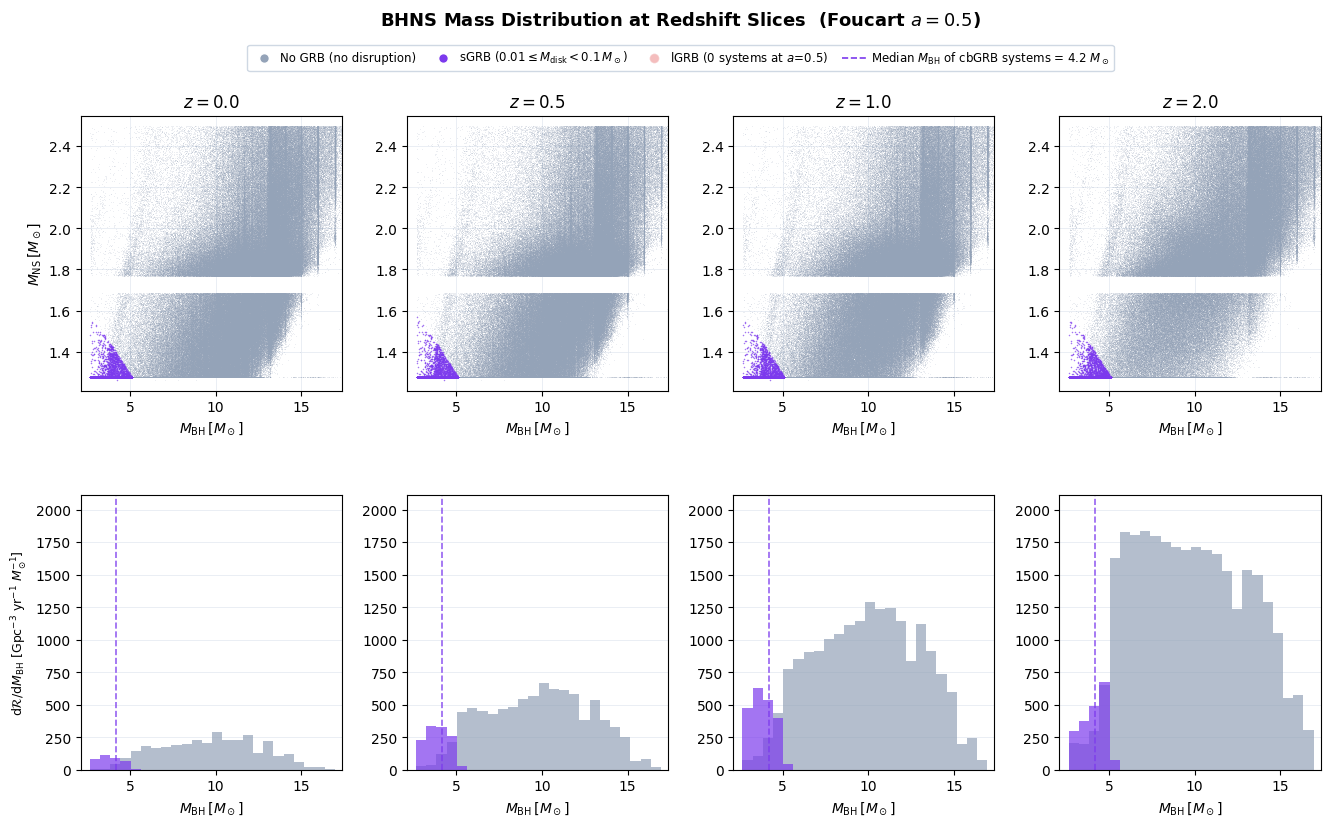

In [19]:
from matplotlib.lines import Line2D

z_slices = [0.0, 0.5, 1.0, 2.0]

_bh_max  = np.percentile(BH, 99)
_bh_pad  = 0.04 * (_bh_max - BH.min())
_ns_pad  = 0.04 * (NS.max() - NS.min())
bh_xlim  = (BH.min() - _bh_pad, _bh_max + _bh_pad)
ns_ylim  = (NS.min() - _ns_pad, NS.max() + _ns_pad)
bins_mbh = np.linspace(BH.min() * 0.99, _bh_max * 1.01, 25)
bw_mbh   = bins_mbh[1] - bins_mbh[0]

has_lgrb = long_BHNS.any()
has_sgrb = short_BHNS.any()
grb_mask = short_BHNS | long_BHNS
mbh_grb_median = np.median(BH[grb_mask]) if grb_mask.any() else np.nan

n_no_z0  = no_BHNS.sum()
n_sg_z0  = short_BHNS.sum()
n_lg_z0  = long_BHNS.sum()
print(f"BHNS classes: No GRB={n_no_z0:,} ({100*no_BHNS.mean():.1f}%)  "
      f"sGRB={n_sg_z0:,} ({100*short_BHNS.mean():.1f}%)  "
      f"lGRB={n_lg_z0:,} ({100*long_BHNS.mean():.1f}%)")
if not np.isnan(mbh_grb_median):
    print(f"Median M_BH of GRB-capable systems: {mbh_grb_median:.1f} M_sun")

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5),
                         gridspec_kw={'hspace': 0.38, 'wspace': 0.25})

_hist_ymaxes = []

for col, z_s in enumerate(z_slices):
    w = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS, delay_BHNS, w_BHNS,
    )

    # === Top row: M_BH vs M_NS scatter ===
    ax = axes[0, col]
    w_thresh = np.percentile(w[w > 0], 60) if (w > 0).any() else 0.0
    vis = w >= w_thresh

    ax.scatter(BH[vis & no_BHNS], NS[vis & no_BHNS],
               s=0.3, c='#94A3B8', alpha=0.20, linewidths=0, zorder=1)
    if has_sgrb:
        ax.scatter(BH[vis & short_BHNS], NS[vis & short_BHNS],
                   s=1.2, c='#7C3AED', alpha=0.70, linewidths=0, zorder=2)
    if has_lgrb:
        ax.scatter(BH[vis & long_BHNS], NS[vis & long_BHNS],
                   s=1.2, c='#DC2626', alpha=0.80, linewidths=0, zorder=3)

    ax.grid(which='major', color='#E2E8F0', lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(*bh_xlim)
    ax.set_ylim(*ns_ylim)
    ax.set_title(f'$z = {z_s}$', fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$M_\mathrm{BH}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$M_\mathrm{NS}\,[M_\odot]$', fontsize=10)

    # === Bottom row: M_BH histogram (normalized per M_sun) ===
    ax2 = axes[1, col]
    n_no, _, _ = ax2.hist(BH[no_BHNS], bins=bins_mbh,
                           weights=w[no_BHNS] / bw_mbh,
                           color='#94A3B8', alpha=0.70)
    _peak = n_no.max()
    if has_sgrb:
        n_sg, _, _ = ax2.hist(BH[short_BHNS], bins=bins_mbh,
                               weights=w[short_BHNS] / bw_mbh,
                               color='#7C3AED', alpha=0.70)
        _peak = max(_peak, n_sg.max())
    if has_lgrb:
        n_lg, _, _ = ax2.hist(BH[long_BHNS], bins=bins_mbh,
                               weights=w[long_BHNS] / bw_mbh,
                               color='#DC2626', alpha=0.70)
        _peak = max(_peak, n_lg.max())
    _hist_ymaxes.append(_peak)

    if not np.isnan(mbh_grb_median):
        ax2.axvline(mbh_grb_median, color='#7C3AED', lw=1.2, ls='--', alpha=0.8)

    ax2.grid(True, which='major', axis='y', color='#E2E8F0', lw=0.5, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_xlim(*bh_xlim)
    ax2.set_ylim(bottom=0)
    ax2.set_xlabel(r'$M_\mathrm{BH}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}M_\mathrm{BH}$'
                        r' [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]', fontsize=9)

_ymax = max(_hist_ymaxes) * 1.15
for ax2 in axes[1]:
    ax2.set_ylim(0, _ymax)

# --- Figure-level shared legend ---
scatter_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#94A3B8',
           markersize=7, label='No GRB (no disruption)'),
]
if has_sgrb:
    scatter_handles.append(
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#7C3AED',
               markersize=7, label=r'sGRB ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$)'))
if has_lgrb:
    scatter_handles.append(
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#DC2626',
               markersize=7, label=r'lGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$)'))
else:
    scatter_handles.append(
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#DC2626',
               markersize=7, alpha=0.3,
               label=r'lGRB (0 systems at $a\!=\!0.5$)'))
if not np.isnan(mbh_grb_median):
    scatter_handles.append(
        Line2D([0],[0], color='#7C3AED', lw=1.2, ls='--',
               label=f'Median $M_\\mathrm{{BH}}$ of cbGRB systems = {mbh_grb_median:.1f} $M_\\odot$'))

fig.legend(handles=scatter_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.97), ncol=len(scatter_handles),
           fontsize=8.5, framealpha=0.92, edgecolor='#CBD5E1',
           columnspacing=1.2, handletextpad=0.4)

fig.suptitle(r'BHNS Mass Distribution at Redshift Slices  (Foucart $a = 0.5$)',
             fontsize=13, fontweight='bold', y=1.005)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_mass_dist_redshift_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 11. Intrinsic Long cbGRB Rate vs Observed lGRB Rate

Compares the predicted intrinsic merger-driven long cbGRB rate (Gottlieb et al. 2023 classification, $M_\mathrm{tot} \geq M_\mathrm{crit}$, $q \geq 1.2$) with the total observed long GRB rate.

**Observational comparison:** Wanderman & Piran (2010) broken-power-law lGRB rate density ($\rho_0 = 1.3\,\mathrm{Gpc^{-3}\,yr^{-1}}$, break at $z = 3.1$). This is a **true (beaming-corrected)** rate derived from the observed luminosity function. The $\times 3$ uncertainty band is a systematic assessment. _Note:_ this is a 2010 estimate; more recent determinations (e.g., Ghirlanda et al. 2016, Lan et al. 2021) may revise both the local rate and its redshift evolution.

**Critical caveat (collapsar contamination):** The W&P rate includes **all** long GRBs, predominantly collapsars, with merger-driven events (GRB 211211A, GRB 230307A; Rastinejad et al. 2025) being a small, recently discovered subclass. The W&P rate is therefore an **upper bound** on the merger-driven long GRB rate. The predicted BNS long cbGRB rate exceeds this upper bound by ~50 to 100x, implying that the Gottlieb $q \geq 1.2$ classification vastly over-predicts the true long cbGRB efficiency ($\varepsilon_\mathrm{grb} \ll 1$ for asymmetric BNS).

**No beaming multiplication** is applied to the predicted intrinsic merger rates, since the W&P rate already accounts for beaming ($f_b \approx 1/200$, $\theta_\mathrm{jet} \approx 5.7°$; Fong et al. 2015).

BNS  lGRB z=0 (eps=1.0):   74.5 Gpc^-3 yr^-1
BNS  lGRB z=0 (eps=0.7):   52.1 Gpc^-3 yr^-1
BHNS lGRB z=0 (a=0.5):     0.00  (peak=0.00)
W&P observed mid   z=0:    1.30 Gpc^-3 yr^-1
Over-prediction at z=0:    57x


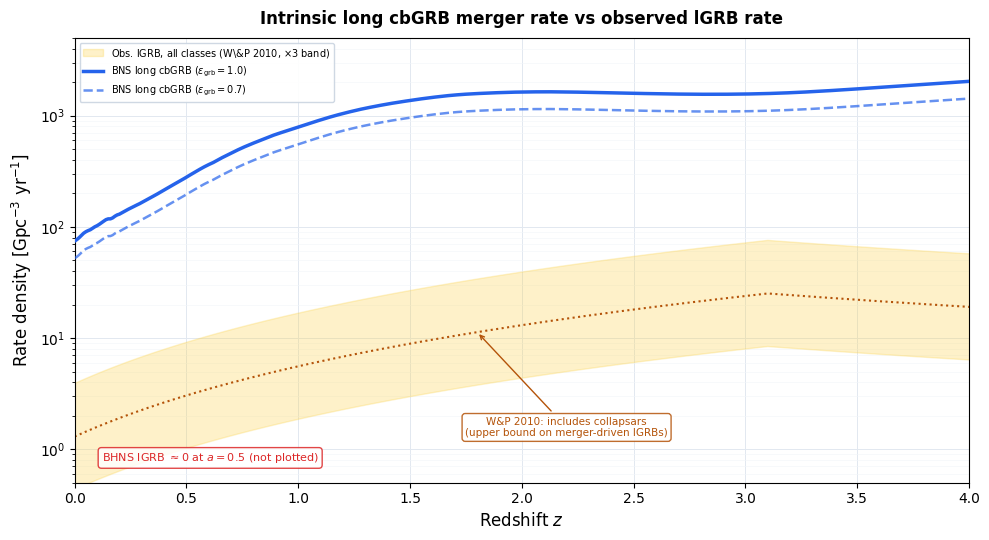

In [20]:
rho0   = 1.3   # Gpc^-3 yr^-1  (Wanderman & Piran 2010, beaming-corrected)
z_br   = 3.1
obs_mid = np.where(redshifts < z_br,
                   rho0 * (1 + redshifts)**2.1,
                   rho0 * (1 + z_br)**2.1 * ((1 + redshifts)/(1 + z_br))**(-1.4))
obs_lo  = obs_mid / 3.0
obs_hi  = obs_mid * 3.0

r_bns_long    = merger_rates_BNS['Long cbGRB']
r_bhns_long   = merger_rates_BHNS['Long cbGRB (a=0.5)']
r_bns_long_07 = merger_rates_BNS_eps07['Long cbGRB']

bhns_lgrb_peak = r_bhns_long.max()
ratio_z0 = r_bns_long[0] / obs_mid[0] if obs_mid[0] > 0 else np.inf

print(f"BNS  lGRB z=0 (eps=1.0):   {r_bns_long[0]:.1f} Gpc^-3 yr^-1")
print(f"BNS  lGRB z=0 (eps=0.7):   {r_bns_long_07[0]:.1f} Gpc^-3 yr^-1")
print(f"BHNS lGRB z=0 (a=0.5):     {r_bhns_long[0]:.2f}  (peak={bhns_lgrb_peak:.2f})")
print(f"W&P observed mid   z=0:    {obs_mid[0]:.2f} Gpc^-3 yr^-1")
print(f"Over-prediction at z=0:    {ratio_z0:.0f}x")

fig, ax = plt.subplots(figsize=(10, 5.5))

# ---- Observed lGRB band (W&P 2010) ----
ax.fill_between(redshifts, obs_lo, obs_hi, color='#FCD34D', alpha=0.30, zorder=1,
                label=r'Obs. lGRB, all classes (W\&P 2010, $\times 3$ band)')
ax.plot(redshifts, obs_mid, color='#B45309', lw=1.5, ls=':', zorder=2)

# ---- BNS long cbGRB ----
ax.plot(redshifts, r_bns_long, color='#2563EB', lw=2.5, ls='-', zorder=3,
        label=r'BNS long cbGRB ($\varepsilon_\mathrm{grb}=1.0$)')
ax.plot(redshifts, r_bns_long_07, color='#2563EB', lw=1.8, ls='--', zorder=3, alpha=0.7,
        label=r'BNS long cbGRB ($\varepsilon_\mathrm{grb}=0.7$)')

# ---- BHNS long cbGRB (only if non-negligible) ----
if bhns_lgrb_peak > 1.0:
    ax.plot(redshifts, r_bhns_long, color='#DC2626', lw=2.0, ls='-.', zorder=3,
            label=r'BHNS long cbGRB ($a=0.5$)')
else:
    ax.text(0.03, 0.04,
            r'BHNS lGRB $\approx 0$ at $a = 0.5$'
            ' (not plotted)',
            transform=ax.transAxes, fontsize=8, color='#DC2626',
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#DC2626', alpha=0.85))

# ---- Annotation: W&P includes collapsars ----
iz = np.argmin(np.abs(redshifts - 1.8))
ax.annotate('W&P 2010: includes collapsars\n(upper bound on merger-driven lGRBs)',
            xy=(redshifts[iz], obs_mid[iz]),
            xytext=(0.55, 0.10), textcoords='axes fraction',
            fontsize=7.5, color='#B45309', ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', color='#B45309', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#B45309', alpha=0.85))



ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
ax.grid(which='minor', color='#F1F5F9', linewidth=0.4, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.set_xlim(0, 4)
ax.set_ylim(5e-1, 5e3)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('Intrinsic long cbGRB merger rate vs observed lGRB rate',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=7, loc='upper left', framealpha=0.92, edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_bns_bhns_dominance.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 13. cbGRB Channel Fraction vs Redshift

Stacked fractional contribution of all four cbGRB channels to the total intrinsic merger-driven GRB rate as a function of redshift. Fractions sum to 100% at each $z$.

**Channels (Gottlieb et al. 2023 classification):**
- **BNS Short cbGRB**: Type I (HMNS, $M_\mathrm{tot} < M_\mathrm{crit}$) + Type II (BH + light disk, $q < 1.2$). Dominant at all $z$.
- **BNS Long cbGRB**: BH + massive disk ($M_\mathrm{tot} \geq M_\mathrm{crit}$, $q \geq 1.2$; Rastinejad et al. 2025). Fraction grows with $z$ as lower metallicity promotes asymmetric mergers.
- **BHNS Short cbGRB**: $0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$ (Foucart 2012/2018). Present at $a = 0.5$ (~9% of BHNS total).
- **BHNS Long cbGRB**: $M_\mathrm{disk} \geq 0.1\,M_\odot$. **Zero** at $a = 0.5$ (Foucart 2012: insufficient spin for massive disk).

**Spin uncertainty envelope:** A shaded band shows how the total BHNS fraction varies across $a = 0.0$ to $0.7$, recomputed with consistent denominators for each spin scenario.

  a=0.0: Long 0  Short 0 systems  z=0 Long: 0.0  Short: 0.0 Gpc⁻³yr⁻¹
  a=0.3: Long 0  Short 2,369 systems  z=0 Long: 0.0  Short: 64.4 Gpc⁻³yr⁻¹


  a=0.7: Long 0  Short 95,883 systems  z=0 Long: 0.0  Short: 609.6 Gpc⁻³yr⁻¹
Absolute rates [Gpc⁻³ yr⁻¹]:
   z     BNS Short    BNS Long    BHNS Short     BHNS Long
   0        1131.6        74.5         221.8           0.0
   1        6819.6       788.2        1242.1           0.0
   2        7354.9      1630.0        1143.7           0.0
   4        4713.6      2033.9         153.6           0.0


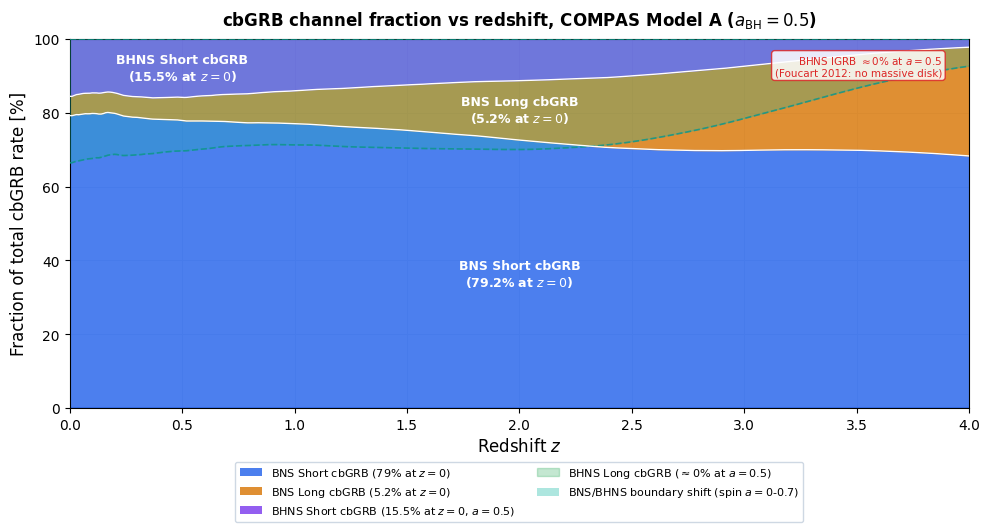


Fractions at key redshifts (fiducial a=0.5):
  z=0: BNS Short 79.2%  BNS Long 5.2%  BHNS Short 15.5%  BHNS Long 0.0%  (BHNS spin range: 0.0-33.6%)
  z=1: BNS Short 77.1%  BNS Long 8.9%  BHNS Short 14.0%  BHNS Long 0.0%  (BHNS spin range: 0.0-28.7%)
  z=2: BNS Short 72.6%  BNS Long 16.1%  BHNS Short 11.3%  BHNS Long 0.0%  (BHNS spin range: 0.0-30.0%)
  z=4: BNS Short 68.3%  BNS Long 29.5%  BHNS Short 2.2%  BHNS Long 0.0%  (BHNS spin range: 0.0-7.4%)


In [21]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

r_bns_short      = merger_rates_BNS['Short cbGRB']
r_bns_long       = merger_rates_BNS['Long cbGRB']
r_bhns_short_fid = merger_rates_BHNS['Short cbGRB (a=0.5)']
r_bhns_long_fid  = merger_rates_BHNS['Long cbGRB (a=0.5)']

if 'merger_rates_BHNS_long_spin' not in dir():
    merger_rates_BHNS_long_spin  = {}
    merger_rates_BHNS_short_spin = {}
    for _a in [0.0, 0.3, 0.7]:
        _disk_a  = foucart_disk_mass(BH, NS, a_BH=_a)
        _long_a  = (_disk_a >= 0.1)
        _short_a = (_disk_a >= 0.01) & (_disk_a < 0.1)
        merger_rates_BHNS_long_spin[_a] = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
            Z_BHNS[_long_a], delay_BHNS[_long_a], w_BHNS[_long_a],
        )
        merger_rates_BHNS_short_spin[_a] = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
            Z_BHNS[_short_a], delay_BHNS[_short_a], w_BHNS[_short_a],
        )
        print(f'  a={_a}: Long {_long_a.sum():,}  Short {_short_a.sum():,} systems'
              f'  z=0 Long: {merger_rates_BHNS_long_spin[_a][0]:.1f}'
              f'  Short: {merger_rates_BHNS_short_spin[_a][0]:.1f} Gpc\u207b\u00b3yr\u207b\u00b9')

r_bhns_long_lo  = merger_rates_BHNS_long_spin[0.0]
r_bhns_long_hi  = merger_rates_BHNS_long_spin[0.7]
r_bhns_short_lo = merger_rates_BHNS_short_spin[0.0]
r_bhns_short_hi = merger_rates_BHNS_short_spin[0.7]

z = redshifts
print("Absolute rates [Gpc\u207b\u00b3 yr\u207b\u00b9]:")
print(f"{'z':>4}  {'BNS Short':>12}  {'BNS Long':>10}  {'BHNS Short':>12}  {'BHNS Long':>12}")
for _zp in [0, 1, 2, 4]:
    _i = np.argmin(np.abs(z - _zp))
    print(f"{_zp:>4}  {r_bns_short[_i]:>12.1f}  {r_bns_long[_i]:>10.1f}"
          f"  {r_bhns_short_fid[_i]:>12.1f}  {r_bhns_long_fid[_i]:>12.1f}")

def _frac4(r_s, r_l, r_bs, r_bl):
    tot = np.where((r_s + r_l + r_bs + r_bl) > 0,
                    r_s + r_l + r_bs + r_bl, np.nan)
    return r_s/tot*100, r_l/tot*100, r_bs/tot*100, r_bl/tot*100

f_short_fid, f_long_fid, f_bhs_fid, f_bhl_fid = _frac4(
    r_bns_short, r_bns_long, r_bhns_short_fid, r_bhns_long_fid)

# Spin envelope: recompute ALL fractions with consistent denominators
f_short_lo, f_long_lo, f_bhs_lo, f_bhl_lo = _frac4(
    r_bns_short, r_bns_long, r_bhns_short_lo, r_bhns_long_lo)
f_short_hi, f_long_hi, f_bhs_hi, f_bhl_hi = _frac4(
    r_bns_short, r_bns_long, r_bhns_short_hi, r_bhns_long_hi)

# Stacked boundaries (fiducial): BNS Short | BNS Long | BHNS Short | BHNS Long
s1 = f_short_fid
s2 = s1 + f_long_fid
s3 = s2 + f_bhs_fid
s4 = s3 + f_bhl_fid  # should be ~100

# Spin envelope for the BNS/BHNS boundary (= 100 - BHNS_total)
bhns_tot_lo = f_bhs_lo + f_bhl_lo
bhns_tot_hi = f_bhs_hi + f_bhl_hi
bns_top_when_bhns_lo = 100.0 - bhns_tot_lo   # BNS share is largest when BHNS is smallest
bns_top_when_bhns_hi = 100.0 - bhns_tot_hi   # BNS share is smallest when BHNS is largest
env_lo = np.minimum(bns_top_when_bhns_lo, bns_top_when_bhns_hi)
env_hi = np.maximum(bns_top_when_bhns_lo, bns_top_when_bhns_hi)

C_s  = '#2563EB'   # blue:   BNS Short
C_l  = '#D97706'   # amber:  BNS Long
C_bs = '#7C3AED'   # purple: BHNS Short
C_bl = '#16A34A'   # green:  BHNS Long

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.fill_between(z, 0,  s1, color=C_s,  alpha=0.82, zorder=2)
ax.fill_between(z, s1, s2, color=C_l,  alpha=0.82, zorder=2)
ax.fill_between(z, s2, s3, color=C_bs, alpha=0.82, zorder=2)
ax.fill_between(z, s3, s4, color=C_bl, alpha=0.82, zorder=2)

ax.fill_between(z, env_lo, env_hi, color='#14B8A6', alpha=0.28, zorder=3,
                label='BNS/BHNS boundary (spin $a=0$-0.7)')
ax.plot(z, env_lo, color='#0D9488', lw=1.2, ls='--', alpha=0.80, zorder=4)
ax.plot(z, env_hi, color='#0D9488', lw=1.2, ls='--', alpha=0.80, zorder=4)

ax.plot(z, s1, color='white', lw=1.0, zorder=5)
ax.plot(z, s2, color='white', lw=1.0, zorder=5)
if f_bhs_fid.max() > 0.5:
    ax.plot(z, s3, color='white', lw=0.7, zorder=5)

_z_max = 4.0
ax.set_xlim(0, _z_max)
ax.set_ylim(0, 100)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Fraction of total cbGRB rate [%]', fontsize=12)
ax.set_title(r'cbGRB channel fraction vs redshift, COMPAS Model A ($a_\mathrm{BH} = 0.5$)',
             fontsize=12, fontweight='bold', pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
ax.set_axisbelow(True)
ax.tick_params(labelsize=10)

# In-band labels at z=2 (mid-range) with z=0 fractions
_iz0 = 0
_iz2 = np.argmin(np.abs(z - 2.0))
for _z_lbl, _bot_arr, _top_arr, _frac_arr, _lbl, _f0 in [
    (2.0, np.zeros_like(s1), s1, f_short_fid, 'BNS Short cbGRB', f_short_fid[_iz0]),
    (2.0, s1,                s2, f_long_fid,  'BNS Long cbGRB',  f_long_fid[_iz0]),
]:
    _iz = np.argmin(np.abs(z - _z_lbl))
    _bot, _top = _bot_arr[_iz], _top_arr[_iz]
    if (_top - _bot) > 5:
        ax.text(_z_lbl, (_bot + _top) / 2,
                f'{_lbl}\n({_f0:.1f}% at $z=0$)',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=6)

# BHNS bands are thin; use external annotations
bhns_short_z0 = f_bhs_fid[_iz0]
bhns_long_z0  = f_bhl_fid[_iz0]
_bhns_mid = (s2[_iz0] + s3[_iz0]) / 2
has_bhns_long = f_bhl_fid.max() > 0.5

for _z_lbl_b, _bot_arr_b, _top_arr_b, _frac_arr_b, _lbl_b, _f0_b in [
    (0.5, s2, s3, f_bhs_fid, 'BHNS Short cbGRB', bhns_short_z0),
]:
    _iz_b = np.argmin(np.abs(z - _z_lbl_b))
    _bot_b, _top_b = _bot_arr_b[_iz_b], _top_arr_b[_iz_b]
    if (_top_b - _bot_b) > 5:
        ax.text(_z_lbl_b, (_bot_b + _top_b) / 2,
                f'{_lbl_b}\n({_f0_b:.1f}% at $z=0$)',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=6)

if not has_bhns_long:
    ax.text(0.97, 0.96,
            r'BHNS lGRB $\approx 0\%$ at $a = 0.5$'
            '\n(Foucart 2012: no massive disk)',
            transform=ax.transAxes, fontsize=7.5, color='#DC2626',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#DC2626', alpha=0.85),
            zorder=7)

legend_handles = [
    Patch(facecolor=C_s,  alpha=0.82, label=f'BNS Short cbGRB ({f_short_fid[0]:.0f}% at $z=0$)'),
    Patch(facecolor=C_l,  alpha=0.82, label=f'BNS Long cbGRB ({f_long_fid[0]:.1f}% at $z=0$)'),
    Patch(facecolor=C_bs, alpha=0.82, label=f'BHNS Short cbGRB ({bhns_short_z0:.1f}% at $z=0$, $a=0.5$)'),
]
if has_bhns_long:
    legend_handles.append(
        Patch(facecolor=C_bl, alpha=0.82, label=f'BHNS Long cbGRB ({bhns_long_z0:.1f}% at $z=0$, $a=0.5$)'))
else:
    legend_handles.append(
        Patch(facecolor=C_bl, alpha=0.25, edgecolor=C_bl,
              label=r'BHNS Long cbGRB ($\approx 0\%$ at $a=0.5$)'))
legend_handles.append(
    Patch(facecolor='#14B8A6', alpha=0.35,
          label='BNS/BHNS boundary shift (spin $a=0$-0.7)'))

ax.legend(handles=legend_handles, fontsize=8, framealpha=0.93,
          edgecolor='#CBD5E1', loc='upper center',
          bbox_to_anchor=(0.5, -0.13), ncol=2)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/grb_channel_fraction_vs_redshift.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nFractions at key redshifts (fiducial a=0.5):")
for _zp in [0, 1, 2, 4]:
    _i = np.argmin(np.abs(z - _zp))
    print(f"  z={_zp}: BNS Short {f_short_fid[_i]:.1f}%  BNS Long {f_long_fid[_i]:.1f}%"
          f"  BHNS Short {f_bhs_fid[_i]:.1f}%  BHNS Long {f_bhl_fid[_i]:.1f}%"
          f"  (BHNS spin range: {bhns_tot_lo[_i]:.1f}-{bhns_tot_hi[_i]:.1f}%)")


## 14. Spin-Marginalized BHNS Long cbGRB Rates

The fiducial BH spin $a = 0.5$ sits at the disruption cliff for typical BHNS mass ratios ($Q \sim 7$; Foucart 2012, Fig. 7). Small changes in spin dramatically shift the BHNS GRB fraction, making the fiducial choice the dominant systematic. Rather than relying on a single spin value, we marginalize BHNS rates over two astrophysically motivated spin priors:

1. **Flat prior** ($p(a) = \text{const}$ on $[0, 1]$): approximated by trapezoidal weights over the four available spin values $a = \{0.0, 0.3, 0.5, 0.7\}$. Weights: $w_0 = 0.15$, $w_{0.3} = 0.25$, $w_{0.5} = 0.20$, $w_{0.7} = 0.40$.
2. **Fuller & Ma (2019) prior**: efficient angular momentum transport predicts natal spins $\chi_\mathrm{BH} \sim 0.0$ to $0.1$ for isolated field binaries. Approximated by placing all weight on the $a = 0.0$ curve.

**Important caveat:** The highest available spin node is $a = 0.7$, which carries weight $w = 0.40$ representing the interval $[0.6, 1.0]$. Foucart (2012) shows that $M_\mathrm{disk}$ increases steeply above $a \gtrsim 0.7$ for $Q \sim 5$ to $7$, so using $a = 0.7$ to proxy for $a = 0.7$ to $1.0$ **underestimates** the flat-prior rate. The flat-prior curve should therefore be regarded as a **lower bound**; the true rate for a uniform spin distribution would be higher.

**Key result:** Even with the optimistic flat prior, BHNS long cbGRB rates remain ~2 orders of magnitude below BNS long cbGRB rates at all redshifts. Under Fuller & Ma (2019), BHNS long cbGRBs are negligible.

Spin-marginalized BHNS long cbGRB rates [Gpc⁻³ yr⁻¹]:
  Prior                      z=0       z=1
  Fiducial a=0.5            0.00      0.00
  Flat [0,1] (lower)        0.00      0.00
  Fuller & Ma 2019          0.00      0.00
  BNS (for ref.)            74.5     788.2
  BNS / BHNS(flat) at z=0: ~infx
  BHNS a=0.7 peak: 0.00  flat-prior peak: 0.00


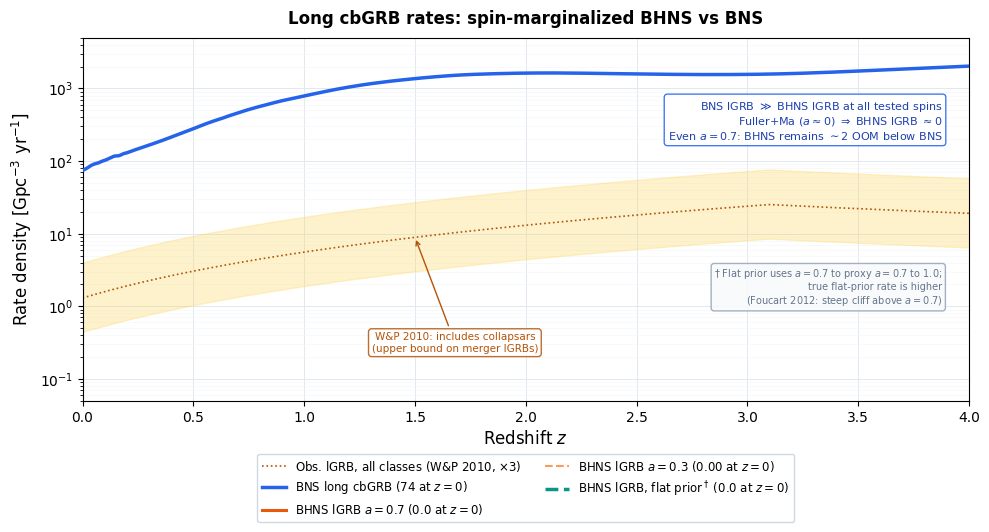


Spin-marginalized BHNS short cbGRB rates [Gpc⁻³ yr⁻¹]:
  Prior                      z=0       z=1
  Fiducial a=0.5          221.81   1242.08
  Flat [0,1]              304.30   1557.44
  Fuller & Ma 2019          0.00      0.00


In [22]:
w_flat = {0.0: 0.15, 0.3: 0.25, 0.5: 0.20, 0.7: 0.40}
w_fm19 = {0.0: 1.0, 0.3: 0.0, 0.5: 0.0, 0.7: 0.0}

spin_long = {
    0.0: merger_rates_BHNS_long_spin[0.0],
    0.3: merger_rates_BHNS_long_spin[0.3],
    0.5: r_bhns_long_fid,
    0.7: merger_rates_BHNS_long_spin[0.7],
}
spin_short = {
    0.0: merger_rates_BHNS_short_spin[0.0],
    0.3: merger_rates_BHNS_short_spin[0.3],
    0.5: r_bhns_short_fid,
    0.7: merger_rates_BHNS_short_spin[0.7],
}

def marginalize(rate_dict, weights):
    return sum(weights[a] * rate_dict[a] for a in rate_dict)

r_bhns_long_flat  = marginalize(spin_long, w_flat)
r_bhns_short_flat = marginalize(spin_short, w_flat)
r_bhns_long_fm19  = marginalize(spin_long, w_fm19)
r_bhns_short_fm19 = marginalize(spin_short, w_fm19)

rho0 = 1.3; z_br = 3.1
obs_mid = np.where(redshifts < z_br,
                   rho0 * (1 + redshifts)**2.1,
                   rho0 * (1 + z_br)**2.1 * ((1 + redshifts)/(1 + z_br))**(-1.4))
obs_lo, obs_hi = obs_mid / 3.0, obs_mid * 3.0

r_bns_long = merger_rates_BNS['Long cbGRB']

_i0 = 0; _i1 = np.argmin(np.abs(redshifts - 1))
ratio_flat = r_bns_long[_i0] / r_bhns_long_flat[_i0] if r_bhns_long_flat[_i0] > 0 else np.inf

print("Spin-marginalized BHNS long cbGRB rates [Gpc\u207b\u00b3 yr\u207b\u00b9]:")
print(f"  {'Prior':<20s}  {'z=0':>8s}  {'z=1':>8s}")
print(f"  {'Fiducial a=0.5':<20s}  {r_bhns_long_fid[_i0]:>8.2f}  {r_bhns_long_fid[_i1]:>8.2f}")
print(f"  {'Flat [0,1] (lower)':<20s}  {r_bhns_long_flat[_i0]:>8.2f}  {r_bhns_long_flat[_i1]:>8.2f}")
print(f"  {'Fuller & Ma 2019':<20s}  {r_bhns_long_fm19[_i0]:>8.2f}  {r_bhns_long_fm19[_i1]:>8.2f}")
print(f"  {'BNS (for ref.)':<20s}  {r_bns_long[_i0]:>8.1f}  {r_bns_long[_i1]:>8.1f}")
print(f"  BNS / BHNS(flat) at z=0: ~{ratio_flat:.0f}x")

r_bhns_07 = merger_rates_BHNS_long_spin[0.7]
r_bhns_03 = merger_rates_BHNS_long_spin[0.3]
r_bhns_00 = merger_rates_BHNS_long_spin[0.0]

peak_07 = r_bhns_07.max()
peak_flat = r_bhns_long_flat.max()
print(f"  BHNS a=0.7 peak: {peak_07:.2f}  flat-prior peak: {peak_flat:.2f}")

fig, ax = plt.subplots(figsize=(10, 5.5))

# ---- Observed lGRB band ----
ax.fill_between(redshifts, obs_lo, obs_hi, color='#FCD34D', alpha=0.28, zorder=1)
ax.plot(redshifts, obs_mid, color='#B45309', lw=1.2, ls=':', zorder=2,
        label=r'Obs. lGRB, all classes (W&P 2010, $\times 3$)')

# ---- BNS long cbGRB ----
ax.plot(redshifts, r_bns_long, color='#2563EB', lw=2.5, zorder=3,
        label=f'BNS long cbGRB ({r_bns_long[0]:.0f} at $z=0$)')

# ---- BHNS individual spin lines ----
ax.plot(redshifts, np.maximum(r_bhns_07, 1e-3),
        color='#EA580C', lw=2.2, ls='-', zorder=3,
        label=f'BHNS lGRB $a=0.7$ ({r_bhns_07[0]:.1f} at $z=0$)')
ax.plot(redshifts, np.maximum(r_bhns_03, 1e-3),
        color='#F97316', lw=1.5, ls='--', alpha=0.7, zorder=3,
        label=f'BHNS lGRB $a=0.3$ ({r_bhns_03[0]:.2f} at $z=0$)')

# ---- BHNS flat prior (teal) ----
ax.plot(redshifts, np.maximum(r_bhns_long_flat, 1e-3),
        color='#0D9488', lw=2.5, ls='--', zorder=4,
        label=f'BHNS lGRB, flat prior$^\\dagger$ ({r_bhns_long_flat[0]:.1f} at $z=0$)')

# ---- BHNS spin range band (a=0.0 to a=0.7) ----
ax.fill_between(redshifts,
                np.maximum(r_bhns_00, 1e-3),
                np.maximum(r_bhns_07, 1e-3),
                color='#EA580C', alpha=0.12, zorder=1)

# ---- Annotation: collapsar caveat on W&P ----
iz_wp = np.argmin(np.abs(redshifts - 1.5))
ax.annotate('W&P 2010: includes collapsars\n(upper bound on merger lGRBs)',
            xy=(redshifts[iz_wp], obs_mid[iz_wp]),
            xytext=(0.42, 0.13), textcoords='axes fraction',
            fontsize=7.5, color='#B45309', ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', color='#B45309', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#B45309', alpha=0.85))

# ---- Annotation: key result (qualitative, no inf ratio) ----
ax.text(0.97, 0.83,
        r'BNS lGRB $\gg$ BHNS lGRB at all tested spins'
        '\n'
        r'Fuller+Ma ($a \approx 0$) $\Rightarrow$ BHNS lGRB $\approx 0$'
        '\n'
        r'Even $a = 0.7$: BHNS remains $\sim$2 OOM below BNS',
        transform=ax.transAxes, fontsize=8, color='#1E40AF',
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#2563EB', alpha=0.85))

# ---- Annotation: flat prior caveat ----
ax.text(0.97, 0.37,
        r'$\dagger$ Flat prior uses $a=0.7$ to proxy $a=0.7$ to $1.0$;'
        '\ntrue flat-prior rate is higher\n(Foucart 2012: steep cliff above $a=0.7$)',
        transform=ax.transAxes, fontsize=7, color='#64748B',
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F8FAFC',
                  edgecolor='#94A3B8', alpha=0.85))

ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
ax.grid(which='minor', color='#F1F5F9', linewidth=0.4, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.set_xlim(0, 4)
ax.set_ylim(5e-2, 5e3)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('Long cbGRB rates: spin-marginalized BHNS vs BNS',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=8.5, framealpha=0.93, edgecolor='#CBD5E1',
          loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_bhns_spin_marginalized.png',
            dpi=150, bbox_inches='tight')
plt.show()

print()
print("Spin-marginalized BHNS short cbGRB rates [Gpc\u207b\u00b3 yr\u207b\u00b9]:")
print(f"  {'Prior':<20s}  {'z=0':>8s}  {'z=1':>8s}")
print(f"  {'Fiducial a=0.5':<20s}  {r_bhns_short_fid[_i0]:>8.2f}  {r_bhns_short_fid[_i1]:>8.2f}")
print(f"  {'Flat [0,1]':<20s}  {r_bhns_short_flat[_i0]:>8.2f}  {r_bhns_short_flat[_i1]:>8.2f}")
print(f"  {'Fuller & Ma 2019':<20s}  {r_bhns_short_fm19[_i0]:>8.2f}  {r_bhns_short_fm19[_i1]:>8.2f}")

## 9. Export

In [23]:
np.save('/Users/josephrodriguez/research visualization/results/rates_BNS.npy',
        np.array([redshifts,
                  merger_rates_BNS['All BNS'],
                  merger_rates_BNS['Short cbGRB'],
                  merger_rates_BNS['Long cbGRB']]))

np.save('/Users/josephrodriguez/research visualization/results/rates_BHNS.npy',
        np.array([redshifts,
                  merger_rates_BHNS['All BHNS'],
                  merger_rates_BHNS['Long cbGRB (a=0.5)']]))

print("Rates saved to rates_BNS.npy and rates_BHNS.npy")

Rates saved to rates_BNS.npy and rates_BHNS.npy
